#  Tumor classification 
dataset 
#  [here](https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset)


# Import libreries

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import tensorflow as tf
tf.get_logger().setLevel('ERROR')  # Suppress TensorFlow logs


In [ ]:
import tensorflow.keras.applications as apps

# List available models in the applications module
print(dir(apps))

In [ ]:
import tensorflow as tf
import warnings

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNet
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D,Dense
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

import matplotlib.pyplot as plt
import os
print(os.getcwd())

# Set Up Paths and Parameters

In [ ]:
# Paths to  dataset
train_dir = '/kaggle/input/brain-tumor-dataset/Brain_Tumor_Multiclass_Dataset/Train'
test_dir = '/kaggle/input/brain-tumor-mri-dataset/Testing'

# Image size and batch size
img_size = 224  # MobileNet requires 224x224 images
batch_size = 32  #
num_classes = 4  # Normal, Glioma, Pituitary, Meningioma


# Data Augmentation and Preprocessing

In [ ]:
# Import necessary libraries
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Data augmentation for training
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Rescaling for validation/test data (no augmentation)
test_datagen = ImageDataGenerator(rescale=1./255)

# Training data generator
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',  # For multi-class classification
    shuffle=True  # Shuffle data for better training
)

# Validation/Test data generator
validation_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical'
)

# Calculate steps per epoch
steps_per_epoch = train_generator.samples // train_generator.batch_size
validation_steps = validation_generator.samples // validation_generator.batch_size

# Debugging information
print(f"Training samples: {train_generator.samples}")
print(f"Validation samples: {validation_generator.samples}")

# Ensure the generators work as intended
for data_batch, labels_batch in train_generator:
    print(f"Data batch shape: {data_batch.shape}")
    print(f"Labels batch shape: {labels_batch.shape}")
    break  # Check the first batch and stop


# Load VGG-19 Base Model

In [ ]:
from tensorflow.keras.applications import VGG19

# Load VGG19 with pre-trained weights, without the top layers
base_model = VGG19(weights='imagenet', include_top=False, input_shape=(img_size, img_size, 3))

# Freeze the base model layers so they are not trainable
base_model.trainable = False


# Build the Model

In [ ]:
# Load VGG19 with pre-trained weights, without the top layers
base_model = VGG19(weights='imagenet', include_top=False, input_shape=(img_size, img_size, 3))

# Freeze the base model layers so they are not trainable
base_model.trainable = False

# Add custom layers on top of VGG19
x = base_model.output
x = GlobalAveragePooling2D()(x)  # Pooling layer
x = Dense(1024, activation='relu')(x)  # Fully connected layer
x = Dense(512, activation='relu')(x)  # Another fully connected layer

# Output layer (4 classes: Notumor, Glioma, Pituitary, Meningioma)
predictions = Dense(num_classes, activation='softmax')(x)

# Create the model
model = Model(inputs=base_model.input, outputs=predictions)

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])

# Print model architecture
model.summary()


# Train the Model

In [ ]:
# Train the model
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=20,  # Adjust the number of epochs
    steps_per_epoch=train_generator.samples // batch_size,
    validation_steps=validation_generator.samples // batch_size
)


# Visualize Training Results (Accuracy & Loss)

In [ ]:
# Plot training & validation accuracy values
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

# Plot training & validation loss values
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()


# Save the model

In [ ]:

model.save('model/brain_tumor_classification_VGG19_mod.h5')


# Prediction validation and plotting confusion matrix with f1 score
These are key performance metrics in binary or multiclass classification tasks. They help evaluate how well a model performs in predicting the true class labels. Here's what each term means along with its formula:

1. Accuracy
Definition: Accuracy is the ratio of correctly predicted instances to the total instances. It tells us the overall correctness of the model but may not be ideal in the case of imbalanced datasets.

 
Where:

TP (True Positive): The model correctly predicted a positive class (e.g., "Tumor Detected").
TN (True Negative): The model correctly predicted a negative class (e.g., "No Tumor").
FP (False Positive): The model incorrectly predicted a positive class (false alarm).
FN (False Negative): The model incorrectly predicted a negative class (missed detection).
2. Precision
Definition: Precision (or Positive Predictive Value) is the ratio of correctly predicted positive instances to the total predicted positives. It indicates how reliable the model’s positive predictions are.



 
High precision means that most predicted positives are actual positives.
A model with high precision has fewer false positives.
3. Recall (Sensitivity or True Positive Rate)
Definition: Recall is the ratio of correctly predicted positive instances to all actual positives. It shows how well the model captures the positive class.


 
High recall means that the model is capturing most of the actual positives.
A model with high recall has fewer false negatives.
4. F1-Score (Harmonic Mean of Precision and Recall)
Definition: The F1-score is the harmonic mean of precision and recall. It provides a balance between precision and recall, especially useful when the dataset is imbalanced.



The F1-score ranges from 0 to 1, where 1 indicates perfect precision and recall.
It's a good metric to consider when there is an uneven class distribution, as it penalizes extreme values of precision or recall.

In [ ]:
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import f1_score

In [ ]:
# Load the saved model
model = load_model('/kaggle/working/model/brain_tumor_classification_VGG19_mod.h5')

# Define the image size
img_size = 224  # Image size used for MobileNet (replace if different)

# Load and preprocess a test image
img_path = '/kaggle/input/brain-tumor-dataset/Brain_Tumor_Multiclass_Dataset/Validation/meningioma/M_101_VF_.jpg'  # Replace with the path to your test image
img = image.load_img(img_path, target_size=(img_size, img_size))
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

# Make prediction
prediction = model.predict(img_array)
predicted_class = np.argmax(prediction, axis=1)

# Class mapping (adjust to your class indices)
class_indices = {0: 'notumor', 1: 'Glioma', 2: 'Pituitary', 3: 'Meningioma'}
print(f"Predicted class: {class_indices[predicted_class[0]]}")


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Assuming your test set is in 'Dataset/Testing' folder, set the path
test_dir = '/kaggle/input/brain-tumor-dataset/Brain_Tumor_Multiclass_Dataset/Validation'

# Image data generator for test images
test_datagen = ImageDataGenerator(rescale=1./255)

# Test data generator
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(img_size, img_size),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

# Generate predictions
Y_pred = model.predict(test_generator)
y_pred = np.argmax(Y_pred, axis=1)
y_true = test_generator.classes


In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

# Plotting confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=test_generator.class_indices.keys(), yticklabels=test_generator.class_indices.keys())
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.show()

# Classification report
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=test_generator.class_indices.keys()))


In [ ]:
# Generate predictions (from the previous step)
Y_pred = model.predict(test_generator)
y_pred = np.argmax(Y_pred, axis=1)
y_true = test_generator.classes


In [ ]:
# Calculate F1 score for each class
f1 = f1_score(y_true, y_pred, average=None)  # F1 score for each class
print(f"F1 Score for each class: {f1}")

# Calculate macro and weighted F1 score
f1_macro = f1_score(y_true, y_pred, average='macro')  # Macro average F1 score
f1_weighted = f1_score(y_true, y_pred, average='weighted')  # Weighted average F1 score

print(f"Macro F1 Score: {f1_macro}")
print(f"Weighted F1 Score: {f1_weighted}")


# Acccuracy,precision,recall and  F score 

# Testing with another dataset

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Assuming your test set is in 'Dataset/Testing' folder, set the path
test_dir = '../btdata/testing'
img_size = 224
# Image data generator for test images
test_datagen = ImageDataGenerator(rescale=1./255)

# Test data generator
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(img_size, img_size),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

# Generate predictions
Y_pred = model.predict(test_generator)
y_pred = np.argmax(Y_pred, axis=1)
y_true = test_generator.classes


In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

# Plotting confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=test_generator.class_indices.keys(), yticklabels=test_generator.class_indices.keys())
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.show()

# Classification report
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=test_generator.class_indices.keys()))


# modifying function to detect presence of tumor

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
import os
from sklearn.metrics import confusion_matrix, accuracy_score
import seaborn as sns
from tqdm import tqdm  # for progress bar

# Load the pre-trained multiclass model (change the path to your model file)
MODEL_PATH = '/kaggle/working/model/brain_tumor_classification_VGG19_mod.h5'
model = tf.keras.models.load_model(MODEL_PATH)

# Class labels (Change these based on your tumor classes)
class_labels = ['Glioma', 'Meningioma', 'Normal', 'Pituitary']

# Define a function to preprocess the image
def prepare_image(img_path):
    img = image.load_img(img_path, target_size=(224, 224))  # Adjust to your model's input size
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array /= 255.0  # Normalize
    return img_array

# Function to predict binary output (tumor vs. no tumor)
def predict_binary(model, img_path):
    img = prepare_image(img_path)
    preds = model.predict(img)
    prediction = np.argmax(preds, axis=1)[0]
    tumor_type = class_labels[prediction]
    
    # Binary classification: 1 for tumor detected, 0 for no tumor
    return 1 if tumor_type != 'Normal' else 0

# Function to load images and true labels from a directory
def load_images_from_directory(directory, true_label, num_images=None):
    images = []
    labels = []
    for i, img_name in enumerate(tqdm(os.listdir(directory))):
        if num_images and i >= num_images:
            break
        img_path = os.path.join(directory, img_name)
        if img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
            images.append(img_path)
            labels.append(true_label)
    return images, labels

# Paths to directories containing test data (change these paths accordingly)
healthy_dir = '/kaggle/input/brain-tumor-dataset/Brain_Tumor_Multiclass_Dataset/Validation/normal'  # No tumor (Healthy)
tumor_dirs = ['/kaggle/input/brain-tumor-dataset/Brain_Tumor_Multiclass_Dataset/Validation/glioma', 
              '/kaggle/input/brain-tumor-dataset/Brain_Tumor_Multiclass_Dataset/Validation/meningioma', 
              '/kaggle/input/brain-tumor-dataset/Brain_Tumor_Multiclass_Dataset/Validation/pituitary']

# Load healthy test images
healthy_images, healthy_labels = load_images_from_directory(healthy_dir, 0)  # 0 = No tumor

# Load tumor test images from each folder and assign labels accordingly
tumor_images = []
tumor_labels = []
for i, tumor_dir in enumerate(tumor_dirs):
    images, labels = load_images_from_directory(tumor_dir, 1)  # 1 = Tumor detected
    tumor_images.extend(images)
    tumor_labels.extend(labels)

# Combine all test images and labels
all_images = healthy_images + tumor_images
true_labels = healthy_labels + tumor_labels

# Predict on test data
predictions = []
for img_path in tqdm(all_images):
    pred = predict_binary(model, img_path)
    predictions.append(pred)



In [ ]:
# plot a matrix

from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import f1_score

In [ ]:
# Calculate accuracy
accuracy = accuracy_score(true_labels, predictions)
print(f"Accuracy: {accuracy * 100:.2f}%")

# Confusion Matrix
conf_matrix = confusion_matrix(true_labels, predictions)

# Plot Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap='Blues', xticklabels=['No Tumor', 'Tumor Detected'], yticklabels=['No Tumor', 'Tumor Detected'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix: Tumor Detection')
plt.show()

# AlexNet

In [ ]:

# Define the input shape and number of classes
img_size = 224  # Image size (adjust as needed)
num_classes = 4  # Number of output classes (e.g., Notumor, Glioma, Pituitary, Meningioma)

# Build AlexNet
alexnet = Sequential([
    # 1st Convolutional Layer
    Conv2D(filters=96, kernel_size=(11, 11), strides=(4, 4), activation='relu', input_shape=(img_size, img_size, 3)),
    MaxPooling2D(pool_size=(3, 3), strides=(2, 2)),

    # 2nd Convolutional Layer
    Conv2D(filters=256, kernel_size=(5, 5), strides=(1, 1), activation='relu', padding='same'),
    MaxPooling2D(pool_size=(3, 3), strides=(2, 2)),

    # 3rd Convolutional Layer
    Conv2D(filters=384, kernel_size=(3, 3), strides=(1, 1), activation='relu', padding='same'),

    # 4th Convolutional Layer
    Conv2D(filters=384, kernel_size=(3, 3), strides=(1, 1), activation='relu', padding='same'),

    # 5th Convolutional Layer
    Conv2D(filters=256, kernel_size=(3, 3), strides=(1, 1), activation='relu', padding='same'),
    MaxPooling2D(pool_size=(3, 3), strides=(2, 2)),

    # Flatten and Fully Connected Layers
    Flatten(),
    Dense(4096, activation='relu'),
    Dropout(0.5),  # Dropout to reduce overfitting
    Dense(4096, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')  # Output layer
])

# Compile the model
alexnet.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Print model architecture
alexnet.summary()

# Train AlexNet

In [ ]:
# Train the model
history = alexnet.fit(
    train_generator, 
    steps_per_epoch=steps_per_epoch, 
    epochs=20,  # Adjust the number of epochs as needed
    validation_data=validation_generator, 
    validation_steps=validation_steps,
)

# Visualize Training Results (Accuracy & Loss)

In [ ]:
# Plot training & validation accuracy values
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

# Plot training & validation loss values
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()


# Save Model

In [ ]:
alexnet.save('model/brain_tumor_classification_VGG19_mod.h5')

# Prediction validation and plotting confusion matrix with f1 score

In [ ]:
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import f1_score

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Assuming your test set is in 'Dataset/Testing' folder, set the path
test_dir = '/kaggle/input/Brain_Tumor_Multiclass_Dataset/Validation'

# Image data generator for test images
test_datagen = ImageDataGenerator(rescale=1./255)

# Test data generator
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(img_size, img_size),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

# Generate predictions
Y_pred = alexnet.predict(test_generator)
y_pred = np.argmax(Y_pred, axis=1)
y_true = test_generator.classes


In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

# Plotting confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Reds", xticklabels=test_generator.class_indices.keys(), yticklabels=test_generator.class_indices.keys())
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.show()

# Classification report
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=test_generator.class_indices.keys()))


AlexNet is overfitting

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.preprocessing import LabelBinarizer

# Assuming your test set is in 'Dataset/Testing' folder, set the path
test_dir = '/kaggle/input/Brain_Tumor_Multiclass_Dataset/Validation'

# Image data generator for test images
test_datagen = ImageDataGenerator(rescale=1./255)

# Test data generator
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(img_size, img_size),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

# Generate predictions
Y_pred = alexnet.predict(test_generator)
y_pred = np.argmax(Y_pred, axis=1)
y_true = test_generator.classes

# Binarize the true labels
lb = LabelBinarizer()
y_true_bin = lb.fit_transform(y_true)

# Calculate the ROC curve and AUC for each class
fpr = {}
tpr = {}
roc_auc = {}

# Iterate over each class
for i in range(y_true_bin.shape[1]):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], Y_pred[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot the ROC curves for each class
plt.figure(figsize=(10, 8))

# Plot ROC curve for each class
for i in range(y_true_bin.shape[1]):
    plt.plot(fpr[i], tpr[i], color='b', lw=2, label=f'Class {i+1} (AUC = {roc_auc[i]:.2f})')

# Plot the diagonal line (random classifier)
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=2)

# Add labels and title
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Multiclass Classification')
plt.legend(loc='lower right')

# Show the plot
plt.show()

In [ ]:
from sklearn.metrics import precision_recall_curve, auc
precision, recall, _ = precision_recall_curve(y_true_bin[:, 1], Y_pred[:, 1])
pr_auc = auc(recall, precision)

plt.plot(recall, precision, label=f'PR Curve (AUC = {pr_auc:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.show()


# EfficientNet

In [ ]:
from tensorflow.keras.applications import MobileNetV3Large

# Load MobileNetV3-Large with pre-trained weights, without the top layers
base_model = MobileNetV3Large(weights='imagenet', include_top=False, input_shape=(img_size, img_size, 3))

# Freeze the base model layers so they are not trainable
base_model.trainable = False


# Compile model

In [ ]:
# Add custom layers on top of EfficientNetB0
x = base_model.output
x = GlobalAveragePooling2D()(x)  # Pooling layer
x = Dense(1024, activation='relu')(x)  # Fully connected layer
x = Dense(512, activation='relu')(x)  # Another fully connected layer

# Output layer (4 classes: Notumor, Glioma, Pituitary, Meningioma)
predictions = Dense(num_classes, activation='softmax')(x)

# Create the model
model = Model(inputs=base_model.input, outputs=predictions)

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])

# Print model architecture
model.summary()


# Train EfficientNet

In [ ]:
warnings.filterwarnings('ignore')

In [ ]:
# Train the model
history = model.fit(
    train_generator, 
    steps_per_epoch=steps_per_epoch, 
    epochs=10,  # Adjust the number of epochs as needed
    validation_data=validation_generator, 
    validation_steps=validation_steps,
)

# Visualize Training Results (Accuracy & Loss)

In [ ]:
# Plot training & validation accuracy values
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

# Plot training & validation loss values
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()


In [ ]:
model.save('model/brain_tumor_classification_Efficient_mod.h5')

# Prediction validation and plotting confusion matrix with f1 score

In [ ]:
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import f1_score

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Assuming your test set is in 'Dataset/Testing' folder, set the path
test_dir = '/kaggle/input/Brain_Tumor_Multiclass_Dataset/Validation'

# Image data generator for test images
test_datagen = ImageDataGenerator(rescale=1./255)

# Test data generator
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(img_size, img_size),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

# Generate predictions
Y_pred = model.predict(test_generator)
y_pred = np.argmax(Y_pred, axis=1)
y_true = test_generator.classes


In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

# Plotting confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="rocket", xticklabels=test_generator.class_indices.keys(), yticklabels=test_generator.class_indices.keys())
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.show()

# Classification report
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=test_generator.class_indices.keys()))


# Train mobilenet_v3

# Visualize Training Results (Accuracy & Loss)

In [ ]:
# Plot training & validation accuracy values
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

# Plot training & validation loss values
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()


# save model

In [ ]:
model.save('/kaggle/working/mobilenetv3_model.h5', save_format='h5', include_optimizer=True)


In [ ]:
from tensorflow.keras.applications import MobileNetV3Large
from tensorflow.keras import layers, models

IMG_SIZE = 224  # Ensure this matches your training setup

# Step 1: Define the same MobileNetV3Large architecture
base_model = MobileNetV3Large(weights=None, include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3), alpha=1.0)

# Keep layers frozen as in training
base_model.trainable = False

# Step 2: Rebuild the Sequential model
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(4, activation="softmax")  # Must match original output classes
])

# Step 3: Load the saved weights
model.load_weights('/kaggle/working/mobilenetv3_model.h5')

# Step 4: Compile again (needed for evaluation & inference)
model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

# Step 5: Verify everything
model.summary()


In [ ]:
import h5py

with h5py.File('/kaggle/working/final_model.h5', 'r') as f:
    print(list(f.keys()))  # Shows what’s inside (weights, model config, etc.)


In [ ]:
!rm /kaggle/working/model/brain_tumor_classification_MobileNet_V3_mod.h5


 # Prediction validation and plotting confusion matrix with f1 score

In [ ]:
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import f1_score
from tensorflow.keras.models import load_model

In [ ]:


model_path = "/kaggle/input/mobilenetv_3/keras/default/1/brain_tumor_classification_mobilenet_mod.h5"
model = load_model(model_path)

from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Assuming your test set is in 'Dataset/Testing' folder, set the path
test_dir = '/kaggle/input/brain-tumor-dataset/Brain_Tumor_Multiclass_Dataset/Validation'

# Image data generator for test images
test_datagen = ImageDataGenerator(rescale=1./255)

# Test data generator
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(img_size, img_size),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

# Generate predictions
Y_pred = model.predict(test_generator)
y_pred = np.argmax(Y_pred, axis=1)
y_true = test_generator.classes


In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

# Plotting confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens", xticklabels=test_generator.class_indices.keys(), yticklabels=test_generator.class_indices.keys())
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.show()

# Classification report
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=test_generator.class_indices.keys()))


# modifying function to detect presence of tumor

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
import os
from sklearn.metrics import confusion_matrix, accuracy_score
import seaborn as sns
from tqdm import tqdm  # for progress bar

# Load the pre-trained multiclass model (change the path to your model file)
MODEL_PATH = '/kaggle/input/mobilenetv_3/keras/default/1/brain_tumor_classification_mobilenet_mod.h5'
model = tf.keras.models.load_model(MODEL_PATH)

# Class labels (Change these based on your tumor classes)
class_labels = ['Glioma', 'Meningioma', 'Normal', 'Pituitary']

# Define a function to preprocess the image
def prepare_image(img_path):
    img = image.load_img(img_path, target_size=(224, 224))  # Adjust to your model's input size
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array /= 255.0  # Normalize
    return img_array

# Function to predict binary output (tumor vs. no tumor)
def predict_binary(model, img_path):
    img = prepare_image(img_path)
    preds = model.predict(img)
    prediction = np.argmax(preds, axis=1)[0]
    tumor_type = class_labels[prediction]
    
    # Binary classification: 1 for tumor detected, 0 for no tumor
    return 1 if tumor_type != 'Normal' else 0

# Function to load images and true labels from a directory
def load_images_from_directory(directory, true_label, num_images=None):
    images = []
    labels = []
    for i, img_name in enumerate(tqdm(os.listdir(directory))):
        if num_images and i >= num_images:
            break
        img_path = os.path.join(directory, img_name)
        if img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
            images.append(img_path)
            labels.append(true_label)
    return images, labels

# Paths to directories containing test data (change these paths accordingly)
healthy_dir = '/kaggle/input/brain-tumor-dataset/Brain_Tumor_Multiclass_Dataset/Validation/normal'  # No tumor (Healthy)
tumor_dirs = ['/kaggle/input/brain-tumor-dataset/Brain_Tumor_Multiclass_Dataset/Validation/glioma', 
              '/kaggle/input/brain-tumor-dataset/Brain_Tumor_Multiclass_Dataset/Validation/meningioma', 
              '/kaggle/input/brain-tumor-dataset/Brain_Tumor_Multiclass_Dataset/Validation/pituitary']

# Load healthy test images
healthy_images, healthy_labels = load_images_from_directory(healthy_dir, 0)  # 0 = No tumor

# Load tumor test images from each folder and assign labels accordingly
tumor_images = []
tumor_labels = []
for i, tumor_dir in enumerate(tumor_dirs):
    images, labels = load_images_from_directory(tumor_dir, 1)  # 1 = Tumor detected
    tumor_images.extend(images)
    tumor_labels.extend(labels)

# Combine all test images and labels
all_images = healthy_images + tumor_images
true_labels = healthy_labels + tumor_labels

# Predict on test data
predictions = []
for img_path in tqdm(all_images):
    pred = predict_binary(model, img_path)
    predictions.append(pred)



In [ ]:
# Calculate accuracy
accuracy = accuracy_score(true_labels, predictions)
print(f"Accuracy: {accuracy * 100:.2f}%")

# Confusion Matrix
conf_matrix = confusion_matrix(true_labels, predictions)

# Plot Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap='Greens', xticklabels=['No Tumor', 'Tumor Detected'], yticklabels=['No Tumor', 'Tumor Detected'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix: Tumor Detection')
plt.show()

# inceptionv3

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import InceptionV3

# Define input size
img_size = 224  # Adjust as needed

# Load InceptionV3 with pre-trained weights, without the top layers
base_model = InceptionV3(weights='imagenet', include_top=False, input_shape=(img_size, img_size, 3))

# Freeze the base model layers
base_model.trainable = False

# Ensure the model is loaded on GPU
with tf.device('/GPU:0'):
    model = base_model


In [ ]:

# Freeze the base model layers
base_model.trainable = False

# Add custom layers on top
x = base_model.output
x = GlobalAveragePooling2D()(x)  # Pooling layer
x = Dense(1024, activation='relu')(x)  # Fully connected layer
x = Dense(512, activation='relu')(x)  # Another fully connected layer

# Output layer
predictions = Dense(num_classes, activation='softmax')(x)

# Create the final model
model = Model(inputs=base_model.input, outputs=predictions)

# Compile and move the model to GPU
with tf.device('/GPU:0'):
    model.compile(optimizer=Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])

# Print model summary
model.summary()


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Define batch size and data augmentation
batch_size = 128  # Adjust based on GPU memory
train_datagen = ImageDataGenerator(rescale=1./255, rotation_range=20, width_shift_range=0.2, 
                                   height_shift_range=0.2, horizontal_flip=True)
val_datagen = ImageDataGenerator(rescale=1./255)

# Load dataset (adjust paths accordingly)
train_generator = train_datagen.flow_from_directory('/kaggle/input/brain-tumor-mri-dataset/Training', target_size=(img_size, img_size),
                                                    batch_size=batch_size, class_mode='categorical')
val_generator = val_datagen.flow_from_directory('/kaggle/input/brain-tumor-mri-dataset/Testing', target_size=(img_size, img_size),
                                                batch_size=batch_size, class_mode='categorical')

# Train model on GPU with no idling
with tf.device('/GPU:0'):
    history = model.fit(train_generator, validation_data=val_generator, epochs=20, 
                        steps_per_epoch=len(train_generator), validation_steps=len(val_generator), verbose=1)


In [ ]:
# Plot training & validation accuracy values
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

# Plot training & validation loss values
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()


In [ ]:
model.save('/kaggle/working/Inceptionv3_model.h5', save_format='h5', include_optimizer=True)


# Evaluation

In [ ]:
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import f1_score
from tensorflow.keras.models import load_model

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Assuming your test set is in 'Dataset/Testing' folder, set the path
test_dir = '/kaggle/input/brain-tumor-dataset/Brain_Tumor_Multiclass_Dataset/Validation'

# Image data generator for test images
test_datagen = ImageDataGenerator(rescale=1./255)

# Test data generator
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(img_size, img_size),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

# Generate predictions
Y_pred = model.predict(test_generator)
y_pred = np.argmax(Y_pred, axis=1)
y_true = test_generator.classes


In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

# Plotting confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="magma", xticklabels=test_generator.class_indices.keys(), yticklabels=test_generator.class_indices.keys())
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.show()

# Classification report
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=test_generator.class_indices.keys()))


# Xception

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import Xception
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# Define input size and number of classes
img_size = 224  # Adjust as needed
num_classes = len(train_generator.class_indices)  # Automatically get class count

# Ensure TensorFlow is using GPU
print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))

# Load Xception with pre-trained weights, without the top layers
base_model = Xception(weights='imagenet', include_top=False, input_shape=(img_size, img_size, 3))

# Freeze the base model layers
base_model.trainable = False

# Add custom layers on top
x = base_model.output
x = GlobalAveragePooling2D()(x)  # Pooling layer
x = Dense(1024, activation='relu')(x)  # Fully connected layer
x = Dropout(0.5)(x)  # Dropout to prevent overfitting
x = Dense(512, activation='relu')(x)
x = Dropout(0.3)(x)

# Output layer
predictions = Dense(num_classes, activation='softmax')(x)

# Create the final model
model = Model(inputs=base_model.input, outputs=predictions)

# Compile the model and move it to GPU
with tf.device('/GPU:0'):
    model.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])
    # Print model summary
    model.summary()

# Early stopping to prevent overfitting
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train the model on GPU
with tf.device('/GPU:0'):
    history = model.fit(
        train_generator,
        steps_per_epoch=steps_per_epoch,
        epochs=20,
        validation_data=validation_generator,
        validation_steps=validation_steps,
        callbacks=[early_stopping]
    )



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import make_interp_spline

# Given data
epochs = np.array(range(1, 12))  # 11 epochs

train_accuracy = np.array([0.6711, 0.8438, 0.7842, 0.8438, 0.8087, 0.8125, 0.8168, 0.6250, 0.8286, 0.7812, 0.8373])
val_accuracy = np.array([0.8672, 0.9355, 0.8766, 0.8387, 0.8938, 0.9677, 0.8719, 0.9355, 0.8977, 0.8710, 0.9086])

train_loss = np.array([0.8247, 0.6028, 0.5596, 0.3577, 0.5006, 0.6731, 0.4694, 0.7143, 0.4504, 0.6573, 0.4303])
val_loss = np.array([0.3637, 0.2389, 0.3300, 0.3541, 0.2766, 0.1860, 0.3102, 0.3330, 0.2887, 0.3370, 0.2628])

# Generate smooth values
epochs_smooth = np.linspace(epochs.min(), epochs.max(), 300)  # More points for a smooth curve

train_acc_smooth = make_interp_spline(epochs, train_accuracy, k=3)(epochs_smooth)
val_acc_smooth = make_interp_spline(epochs, val_accuracy, k=3)(epochs_smooth)
train_loss_smooth = make_interp_spline(epochs, train_loss, k=3)(epochs_smooth)
val_loss_smooth = make_interp_spline(epochs, val_loss, k=3)(epochs_smooth)

# Plot Accuracy
plt.figure(figsize=(10, 5))
plt.plot(epochs_smooth, train_acc_smooth, color='blue', linestyle='-', label='Training Accuracy')  
plt.plot(epochs_smooth, val_acc_smooth, color='orange', linestyle='-', label='Validation Accuracy')  
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='upper left')
plt.grid(True)
plt.show()

# Plot Loss
plt.figure(figsize=(10, 5))
plt.plot(epochs_smooth, train_loss_smooth, color='blue', linestyle='-', label='Training Loss')
plt.plot(epochs_smooth, val_loss_smooth, color='orange', linestyle='-', label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper left')
plt.grid(True)
plt.show()


In [ ]:
model.save("Xception_brain_tumor.h5")

# Evaluation

In [ ]:
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import f1_score
from tensorflow.keras.models import load_model

from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Assuming your test set is in 'Dataset/Testing' folder, set the path
test_dir = '/kaggle/input/brain-tumor-mri-dataset/Testing'

# Image data generator for test images
test_datagen = ImageDataGenerator(rescale=1./255)

# Test data generator
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(img_size, img_size),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

# Generate predictions
Y_pred = model.predict(test_generator)
y_pred = np.argmax(Y_pred, axis=1)
y_true = test_generator.classes


# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

# Plotting confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greys", xticklabels=test_generator.class_indices.keys(), yticklabels=test_generator.class_indices.keys())
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.show()

# Classification report
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=test_generator.class_indices.keys()))



another dataset

In [ ]:
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import f1_score
from tensorflow.keras.models import load_model

from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Assuming your test set is in 'Dataset/Testing' folder, set the path
test_dir = '/kaggle/input/brain-tumor-dataset/Brain_Tumor_Multiclass_Dataset/Validation'

# Image data generator for test images
test_datagen = ImageDataGenerator(rescale=1./255)

# Test data generator
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(img_size, img_size),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

# Generate predictions
Y_pred = model.predict(test_generator)
y_pred = np.argmax(Y_pred, axis=1)
y_true = test_generator.classes


# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

# Plotting confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greys", xticklabels=test_generator.class_indices.keys(), yticklabels=test_generator.class_indices.keys())
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.show()

# Classification report
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=test_generator.class_indices.keys()))



In [ ]:
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import f1_score
from tensorflow.keras.models import load_model

from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Assuming your test set is in 'Dataset/Testing' folder, set the path
test_dir = '/kaggle/input/brain-tumor-classification-mri/Training'

# Image data generator for test images
test_datagen = ImageDataGenerator(rescale=1./255)

# Test data generator
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(img_size, img_size),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

# Generate predictions
Y_pred = model.predict(test_generator)
y_pred = np.argmax(Y_pred, axis=1)
y_true = test_generator.classes


# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

# Plotting confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greys", xticklabels=test_generator.class_indices.keys(), yticklabels=test_generator.class_indices.keys())
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.show()

# Classification report
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=test_generator.class_indices.keys()))



In [ ]:
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("GPU is enabled")
    except RuntimeError as e:
        print(e)


In [ ]:
# Import necessary libraries
import tensorflow as tf
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Flatten, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam

# Load DenseNet121 as base model (pretrained on ImageNet)
base_model = DenseNet121(
    weights="imagenet",  # Use pretrained weights
    include_top=False,   # Exclude final dense layers
    input_shape=(224, 224, 3)  # Match your dataset image size
)

# Freeze base model layers to prevent training (optional, good for small datasets)
base_model.trainable = False  # Change to True if fine-tuning

# Add custom classification head
x = base_model.output
x = GlobalAveragePooling2D()(x)  # Global pooling to reduce dimensions
x = Dense(512, activation='relu')(x)  # Fully connected layer
x = Dropout(0.5)(x)  # Dropout for regularization
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
output_layer = Dense(4, activation='softmax', name="output_layer")(x)  # 4-class classification

# Define model
model = Model(inputs=base_model.input, outputs=output_layer)

# Compile model
model.compile(
    optimizer=Adam(learning_rate=0.0001),  # Lower LR for stable training
    loss="categorical_crossentropy",  # Multi-class classification
    metrics=["accuracy"]
)

# Model summary
model.summary()


In [ ]:
# Stop training if validation loss does not improve after 5 epochs
early_stopping = EarlyStopping(
    monitor='val_loss', patience=5, restore_best_weights=True, verbose=1
)

# Reduce learning rate if validation loss plateaus
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7, verbose=1
)

# Save best model during training
checkpoint = ModelCheckpoint(
    "best_densenet_model.keras", monitor="val_loss", save_best_only=True, verbose=1
)

# Combine callbacks
callbacks = [early_stopping, reduce_lr, checkpoint]


In [ ]:
history_finetune = model.fit(
    train_generator,
    epochs=20,
    validation_data=validation_generator,
    steps_per_epoch=steps_per_epoch,
    validation_steps=validation_steps,
    callbacks=callbacks
)


# Pytorch

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.models as models
from torchvision import datasets
from torch.utils.data import DataLoader
import time
import copy
import matplotlib.pyplot as plt


In [ ]:
# Check for GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Hyperparameters
batch_size = 32
learning_rate = 0.001
num_epochs = 20
image_size = 224  # Required for DenseNet


In [ ]:
# Define transformations for training and validation
train_transforms = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

val_transforms = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

# Load datasets
train_dataset = datasets.ImageFolder(root="/kaggle/input/brain-tumor-dataset/Brain_Tumor_Multiclass_Dataset/Train", transform=train_transforms)
val_dataset = datasets.ImageFolder(root="/kaggle/input/brain-tumor-dataset/Brain_Tumor_Multiclass_Dataset/Validation", transform=val_transforms)

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

# Print class indices
class_names = train_dataset.classes
print(f"Classes: {class_names}")


# DenseNet

In [ ]:
# Load DenseNet-121 with pretrained weights
model = models.densenet121(pretrained=False)

# Modify the classifier to match the number of classes
num_features = model.classifier.in_features
model.classifier = nn.Linear(num_features, len(class_names))

# Move model to GPU if available
model = model.to(device)

# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)


In [ ]:
def train_model(model, criterion, optimizer, num_epochs=10):
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    for epoch in range(num_epochs):
        print(f"Epoch {epoch+1}/{num_epochs}")

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
                data_loader = train_loader
            else:
                model.eval()
                data_loader = val_loader

            running_loss = 0.0
            correct = 0
            total = 0

            for inputs, labels in data_loader:
                inputs, labels = inputs.to(device), labels.to(device)

                optimizer.zero_grad()
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    loss = criterion(outputs, labels)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                _, preds = torch.max(outputs, 1)
                correct += (preds == labels).sum().item()
                total += labels.size(0)

            epoch_loss = running_loss / len(data_loader.dataset)
            epoch_acc = correct / total

            history[f"{phase}_loss"].append(epoch_loss)
            history[f"{phase}_acc"].append(epoch_acc)

            print(f"{phase.upper()} - Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}")

            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())

    print("Best Validation Accuracy:", best_acc)
    model.load_state_dict(best_model_wts)
    return model, history


In [ ]:
from torchinfo import summary

summary(model, input_size=(1, 3, 224, 224))  # Batch size 1, 3 color channels, 224x224 image


In [ ]:
trained_model, history = train_model(model, criterion, optimizer, num_epochs)


In [ ]:
torch.save(trained_model.state_dict(), "brain_tumor_densenet.pth")
print("Model saved successfully!")


In [ ]:
plt.figure(figsize=(12, 4))

# Loss plot
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.legend()
plt.title('Loss over epochs')

# Accuracy plot
plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], label='Train Accuracy')
plt.plot(history['val_acc'], label='Validation Accuracy')
plt.legend()
plt.title('Accuracy over epochs')

plt.show()


# Evaluation

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Function to evaluate the model and collect predictions
def evaluate_model(model, dataloader):
    model.eval()
    true_labels = []
    pred_labels = []
    
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            true_labels.extend(labels.cpu().numpy())
            pred_labels.extend(preds.cpu().numpy())

    return np.array(true_labels), np.array(pred_labels)


In [ ]:
# Get true and predicted labels
true_labels, pred_labels = evaluate_model(trained_model, val_loader)

# Compute confusion matrix
cm = confusion_matrix(true_labels, pred_labels)

# Plot confusion matrix
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()
# Print classification report
print("Classification Report:\n", classification_report(true_labels, pred_labels, target_names=class_names))


# Binary classification testing

In [ ]:
import torch
import torch.nn as nn
import torchvision.transforms as transforms
from torchvision import models
from PIL import Image
import numpy as np
import os
from tqdm import tqdm
from sklearn.metrics import confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# Load the pre-trained DenseNet model
MODEL_PATH = "/kaggle/working/brain_tumor_densenet.pth"  # Update with your model path
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Define the same class labels
class_labels = ['Glioma', 'Meningioma', 'Normal', 'Pituitary']

# Load the model
model = models.densenet121(pretrained=False)
num_ftrs = model.classifier.in_features
model.classifier = nn.Linear(num_ftrs, len(class_labels))  # Adjust for 4 classes

model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model.to(device)
model.eval()  # Set to evaluation mode

# Image transformations (same size as training)
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])  # Normalize (adjust based on training)
])

# Function to preprocess and predict an image
def predict_binary(model, img_path):
    img = Image.open(img_path).convert("RGB")
    img = transform(img).unsqueeze(0).to(device)  # Add batch dimension
    with torch.no_grad():
        preds = model(img)
        prediction = torch.argmax(preds, dim=1).item()
    
    tumor_type = class_labels[prediction]
    return 1 if tumor_type != 'Normal' else 0  # 1 = Tumor, 0 = No tumor

# Function to load images and true labels from a directory
def load_images_from_directory(directory, true_label):
    images = []
    labels = []
    for img_name in tqdm(os.listdir(directory)):
        img_path = os.path.join(directory, img_name)
        if img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
            images.append(img_path)
            labels.append(true_label)
    return images, labels

# Define dataset paths
healthy_dir = "/kaggle/input/brain-tumor-dataset/Brain_Tumor_Multiclass_Dataset/Validation/normal"
tumor_dirs = [
    "/kaggle/input/brain-tumor-dataset/Brain_Tumor_Multiclass_Dataset/Validation/glioma",
    "/kaggle/input/brain-tumor-dataset/Brain_Tumor_Multiclass_Dataset/Validation/meningioma",
    "/kaggle/input/brain-tumor-dataset/Brain_Tumor_Multiclass_Dataset/Validation/pituitary"
]

# Load images
healthy_images, healthy_labels = load_images_from_directory(healthy_dir, 0)  # No tumor
tumor_images, tumor_labels = [], []

for tumor_dir in tumor_dirs:
    images, labels = load_images_from_directory(tumor_dir, 1)  # Tumor detected
    tumor_images.extend(images)
    tumor_labels.extend(labels)

# Combine test images & labels
all_images = healthy_images + tumor_images
true_labels = healthy_labels + tumor_labels

# Perform predictions
predictions = [predict_binary(model, img) for img in tqdm(all_images)]

# Compute accuracy
accuracy = accuracy_score(true_labels, predictions)
print(f"Accuracy: {accuracy:.4f}")

# Plot confusion matrix
conf_matrix = confusion_matrix(true_labels, predictions)
plt.figure(figsize=(5, 5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='BuGn', xticklabels=["No Tumor", "Tumor"], yticklabels=["No Tumor", "Tumor"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


# Densenet

# Evaluation

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Function to evaluate the model and collect predictions
def evaluate_model(model, dataloader):
    model.eval()
    true_labels = []
    pred_labels = []
    
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            true_labels.extend(labels.cpu().numpy())
            pred_labels.extend(preds.cpu().numpy())

    return np.array(true_labels), np.array(pred_labels)


# Trsting with other dataset
models in pytorch achieved good accuracy,so testing with other dataset to see if model is overfitting

In [ ]:
print(model)

In [ ]:
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.datasets as datasets
import torchvision.models as models
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

# Define device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load test dataset to get class names
test_dataset = datasets.ImageFolder(root="/kaggle/input/brain-tumor-mri-dataset/Testing")
class_names = test_dataset.classes  # Get detected class names
num_classes = len(class_names)  # Should be 4

# Load DenseNet without pretrained weights
model = models.densenet121(pretrained=False)

# Modify the classifier layer to match the number of classes
num_features = model.classifier.in_features  # DenseNet uses 'classifier'
model.classifier = nn.Linear(num_features, num_classes)  # Replace last layer

# Load trained weights
model_path = "/kaggle/working/brain_tumor_densenet.pth"  # Update path if needed
model.load_state_dict(torch.load(model_path, map_location=device))  # Load weights
model.to(device)
model.eval()  # Set model to evaluation mode

print("Model Loaded Successfully with Structure:\n", model)


In [ ]:
# Define image transformations (same as training)
img_size = 224  # EfficientNet-B0 input size
transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Load test dataset with transformations
test_dataset = datasets.ImageFolder(root="/kaggle/input/brain-tumor-dataset/Brain_Tumor_Multiclass_Dataset/Validation", transform=transform)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=32, shuffle=False)

print("Test Dataset Loaded with Classes:", class_names)


In [ ]:
# Initialize lists for predictions and true labels
y_true, y_pred = [], []

# Run inference
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

print("Model Inference Completed.")


In [ ]:
# Generate Confusion Matrix
conf_matrix = confusion_matrix(y_true, y_pred)

# Plot Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

# Print Classification Report
print("Classification Report:\n", classification_report(y_true, y_pred, labels=list(range(num_classes)), target_names=class_names))


In [ ]:
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.models as models
import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image

# Load EfficientNet-B0 Model
MODEL_PATH = "/kaggle/working/brain_tumor_Efficientnet.pth"  # Update path
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load EfficientNet-B0
model = models.efficientnet_b0(pretrained=False)
num_ftrs = model.classifier[1].in_features  # EfficientNet-B0 classifier layer
model.classifier[1] = nn.Linear(num_ftrs, 4)  # Assuming 4 classes
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model.to(device)
model.eval()

# Image preprocessing (EfficientNet-B0 normalization)
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])  # EfficientNet normalization
])

# Define hooks for gradients & activations
gradients = None
activations = None

def save_gradients(module, grad_in, grad_out):
    global gradients
    gradients = grad_out[0]  # Save gradients

def save_activations(module, input, output):
    global activations
    activations = output  # Save activations

# Function to generate Grad-CAM
def generate_grad_cam(image_path, model, target_layer):
    global gradients, activations
    img = Image.open(image_path).convert("RGB")
    input_tensor = transform(img).unsqueeze(0).to(device)  # Convert image to tensor

    # Register hooks for activations & gradients
    handle_act = target_layer.register_forward_hook(save_activations)
    handle_grad = target_layer.register_full_backward_hook(save_gradients)

    # Forward pass
    output = model(input_tensor)
    pred_class = torch.argmax(output, dim=1).item()

    # Backward pass to get gradients
    model.zero_grad()
    output[:, pred_class].backward()

    # Remove hooks
    handle_act.remove()
    handle_grad.remove()

    # Compute Grad-CAM
    gradients_np = gradients.cpu().numpy()  # Convert to NumPy
    activations_np = activations.detach().cpu().numpy()

    weights = np.mean(gradients_np, axis=(2, 3))  # Global average pooling
    cam = np.sum(weights[:, :, None, None] * activations_np, axis=1)
    cam = np.maximum(cam, 0)  # ReLU to keep positive values
    cam = cam[0]  # Remove batch dimension

    # Resize cam to image size
    cam = cv2.resize(cam, (224, 224))
    cam = (cam - cam.min()) / (cam.max() - cam.min())  # Normalize

    # Overlay on image
    img_cv = np.array(img)
    img_cv = cv2.resize(img_cv, (224, 224))
    heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
    overlayed = cv2.addWeighted(img_cv, 0.5, heatmap, 0.5, 0)

    # Show result
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(img)
    plt.title("Original Image")

    plt.subplot(1, 2, 2)
    plt.imshow(overlayed)
    plt.title(f"Grad-CAM (Class: {pred_class})")
    plt.show()

# Select the last convolutional layer in EfficientNet-B0
target_layer = model.features[-1]  # Last convolutional layer of EfficientNet-B0

# Run Grad-CAM on an image
image_path = "/kaggle/input/brain-tumor-dataset/Brain_Tumor_Multiclass_Dataset/Validation/pituitary/P_101_HF_.jpg"  # Update path
generate_grad_cam(image_path, model, target_layer)


# testing mobilenet model with other datasets

In [ ]:
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import f1_score

# Load the saved model
model = load_model('/kaggle/input/mobilenetv_3/keras/default/1/brain_tumor_classification_mobilenet_mod.h5')

# Define the image size
img_size = 224  # Image size used for MobileNet (replace if different)

# Load and preprocess a test image
img_path = '/kaggle/input/brain-tumor-dataset/Brain_Tumor_Multiclass_Dataset/Validation/meningioma/M_101_VF_.jpg'  # Replace with the path to your test image
img = image.load_img(img_path, target_size=(img_size, img_size))
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

# Make prediction
prediction = model.predict(img_array)
predicted_class = np.argmax(prediction, axis=1)

# Class mapping (adjust to your class indices)
class_indices = {0: 'notumor', 1: 'Glioma', 2: 'Pituitary', 3: 'Meningioma'}
print(f"Predicted class: {class_indices[predicted_class[0]]}")


from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Assuming your test set is in 'Dataset/Testing' folder, set the path
test_dir = '/kaggle/input/brain-tumor-mri-dataset/Testing'
img_size = 224
# Image data generator for test images
test_datagen = ImageDataGenerator(rescale=1./255)

# Test data generator
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(img_size, img_size),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

# Generate predictions
Y_pred = model.predict(test_generator)
y_pred = np.argmax(Y_pred, axis=1)
y_true = test_generator.classes


# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

# Plotting confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=test_generator.class_indices.keys(), yticklabels=test_generator.class_indices.keys())
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.show()

# Classification report
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=test_generator.class_indices.keys()))


In [ ]:
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import f1_score

# Load the saved model
model = load_model('/kaggle/input/mobilenetv_3/keras/default/1/brain_tumor_classification_mobilenet_mod.h5')

# Define the image size
img_size = 224  # Image size used for MobileNet (replace if different)

# Load and preprocess a test image
img_path = '/kaggle/input/brain-tumor-classification-mri/Testing/meningioma_tumor/image(10).jpg'  # Replace with the path to your test image
img = image.load_img(img_path, target_size=(img_size, img_size))
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

# Make prediction
prediction = model.predict(img_array)
predicted_class = np.argmax(prediction, axis=1)

# Class mapping (adjust to your class indices)
class_indices = {0: 'notumor', 1: 'Glioma', 2: 'Pituitary', 3: 'Meningioma'}
print(f"Predicted class: {class_indices[predicted_class[0]]}")


from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Assuming your test set is in 'Dataset/Testing' folder, set the path
test_dir = '/kaggle/input/brain-tumor-classification-mri/Training'
img_size = 224
# Image data generator for test images
test_datagen = ImageDataGenerator(rescale=1./255)

# Test data generator
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(img_size, img_size),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

# Generate predictions
Y_pred = model.predict(test_generator)
y_pred = np.argmax(Y_pred, axis=1)
y_true = test_generator.classes


# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

# Plotting confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=test_generator.class_indices.keys(), yticklabels=test_generator.class_indices.keys())
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.show()

# Classification report
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=test_generator.class_indices.keys()))


In [ ]:
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import f1_score

# Load the saved model
model = load_model('/kaggle/input/mobilenetv_3/keras/default/1/brain_tumor_classification_mobilenet_mod.h5')

# Define the image size
img_size = 224  # Image size used for MobileNet (replace if different)

# Load and preprocess a test image
img_path = '/kaggle/input/brain-tumor-mri-dataset/Training/notumor/Tr-noTr_0001.jpg'  # Replace with the path to your test image
img = image.load_img(img_path, target_size=(img_size, img_size))
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

# Make prediction
prediction = model.predict(img_array)
predicted_class = np.argmax(prediction, axis=1)

# Class mapping (adjust to your class indices)
class_indices = {0: 'notumor', 1: 'Glioma', 2: 'Pituitary', 3: 'Meningioma'}
print(f"Predicted class: {class_indices[predicted_class[0]]}")


from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Assuming your test set is in 'Dataset/Testing' folder, set the path
test_dir = '/kaggle/input/brain-tumor-mri-dataset/Training'
img_size = 224
# Image data generator for test images
test_datagen = ImageDataGenerator(rescale=1./255)

# Test data generator
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(img_size, img_size),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

# Generate predictions
Y_pred = model.predict(test_generator)
y_pred = np.argmax(Y_pred, axis=1)
y_true = test_generator.classes


# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

# Plotting confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=test_generator.class_indices.keys(), yticklabels=test_generator.class_indices.keys())
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.show()

# Classification report
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=test_generator.class_indices.keys()))


# MobileNetV3_Large

In [ ]:
from tensorflow.keras.applications import MobileNetV3Large
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense
from tensorflow.keras.optimizers import Adam

# Load MobileNetV3Large with pre-trained weights, without the top layers
base_model = MobileNetV3Large(weights='imagenet', include_top=False, input_shape=(img_size, img_size, 3))

# Freeze the base model layers so they are not trainable
base_model.trainable = False

# Add custom layers on top of MobileNetV3Large
x = base_model.output
x = GlobalAveragePooling2D()(x)  # Pooling layer
x = Dense(1024, activation='relu')(x)  # Fully connected layer
x = Dense(512, activation='relu')(x)  # Another fully connected layer

# Output layer (4 classes: Notumor, Glioma, Pituitary, Meningioma)
predictions = Dense(num_classes, activation='softmax')(x)

# Create the model
model = Model(inputs=base_model.input, outputs=predictions)

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])

# Print model architecture
model.summary()


In [ ]:
# Train the model using GPU
import tensorflow as tf

# Ensure TensorFlow runs on GPU if available
device = "/GPU:0" if tf.config.list_physical_devices('GPU') else "/CPU:0"
print(f"Using device: {device}")

with tf.device(device):
    history = model.fit(
        train_generator,
        validation_data=validation_generator,
        epochs=20,  # Adjust the number of epochs
        steps_per_epoch=train_generator.samples // batch_size,
        validation_steps=validation_generator.samples // batch_size,
        verbose=2  # Show progress without idle time
    )


In [ ]:
model.save("MobileNetV3_Large.h5")

In [ ]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy
plt.figure(figsize=(12, 5))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid()

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid()

plt.show()



\begin{array}{|c|c|c|c|c|c|c|c|}
\hline
\textbf{Model} & \textbf{Accuracy} & \textbf{Precision} & \textbf{Recall} & \textbf{F1-Score} & \textbf{Generalization} & \textbf{Dataset Consistency} & \textbf{Remarks} \\
\hline
\textbf{\color{green}MobileNetV3} & \textbf{\color{green}0.95} & \textbf{\color{green}0.95} & \textbf{\color{green}0.96} & \textbf{\color{green}0.95} & \textbf{\color{green}Excellent} & \textbf{\color{green}High (Multiple Datasets)} & \textbf{\color{green}Best Model, Well Generalized} \\
\hline
\color{green}Xception & \color{green}0.85 & \color{green}0.86 & \color{green}0.85 & \color{green}0.85 & \color{green}Good & \color{green}Moderate & \color{green}Well Generalized, Reliable \\
\hline
\color{yellow}VGG-19 & \color{yellow}0.83 & \color{yellow}0.83 & \color{yellow}0.84 & \color{yellow}0.83 & \color{yellow}Moderate & \color{yellow}Moderate & \color{yellow}Heavy Model, Decent Performance \\
\hline
\color{yellow}InceptionV3 & \color{yellow}0.82 & \color{yellow}0.82 & \color{yellow}0.83 & \color{yellow}0.81 & \color{yellow}Moderate & \color{yellow}Moderate & \color{yellow}Weak on Meningioma \\
\hline
\color{orange}DenseNet121 & \color{orange}0.99 & \color{orange}0.99 & \color{orange}0.99 & \color{orange}0.99 & \color{orange}Overfitting & \color{orange}Poor & \color{orange}Needs Regularization, Overfits Training Data \\
\hline
\color{red}EfficientNetB0 & \color{red}0.20 & \color{red}0.07 & \color{red}0.25 & \color{red}0.11 & \color{red}Failed & \color{red}Very Poor & \color{red}Completely Misclassified \\
\hline
\color{red}AlexNet & \color{red}0.28 & \color{red}0.07 & \color{red}0.25 & \color{red}0.11 & \color{red}Failed & \color{red}Very Poor & \color{red}Only Predicts Meningioma, Unusable \\
\hline
\end{array}




\begin{array}{|c|c|c|c|c|c|c|}
\hline
\textbf{Model} & \textbf{Precision} & \textbf{Recall} & \textbf{F1-Score} & \textbf{Accuracy} & \textbf{Generalization} & \textbf{Remarks} \\
\hline
\rowcolor{green!20} \textbf{MobileNetV3} & 0.95 & 0.96 & 0.95 & 0.95 & \textbf{Excellent} & \textbf{Best performing model, well generalized across datasets} \\
\hline
\rowcolor{green!10} \textbf{Xception} & 0.86 & 0.85 & 0.85 & 0.85 & \textbf{Good} & Strong feature extraction, robust performance \\
\hline
\rowcolor{yellow!20} \textbf{InceptionV3} & 0.82 & 0.83 & 0.81 & 0.82 & Moderate & Good for multi-scale tumor detection, struggles with meningioma \\
\hline
\rowcolor{yellow!10} \textbf{VGG-19} & 0.83 & 0.84 & 0.83 & 0.83 & Moderate & Decent accuracy but computationally heavy \\
\hline
\rowcolor{red!20} \textbf{DenseNet121} & 0.99 & 0.99 & 0.99 & 0.99 & Poor & \textbf{Severe overfitting, unusable for real-world cases} \\
\hline
\rowcolor{red!10} \textbf{EfficientNetB0} & 0.08 & 0.28 & 0.12 & 0.20 & Poor & \textbf{Underfitting, fails on complex images} \\
\hline
\rowcolor{red!30} \textbf{AlexNet} & 0.07 & 0.25 & 0.11 & 0.28 & Poor & Outdated, lacks depth for medical imaging \\
\hline
\end{array}


In [ ]:
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.models as models
import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image

# Load EfficientNet-B0 Model
MODEL_PATH = "/kaggle/working/brain_tumor_Efficientnet.pth"  # Update path
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load EfficientNet-B0
model = models.efficientnet_b0(pretrained=False)
num_ftrs = model.classifier[1].in_features  # EfficientNet-B0 classifier layer
model.classifier[1] = nn.Linear(num_ftrs, 4)  # Assuming 4 classes
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model.to(device)
model.eval()

# Image preprocessing (EfficientNet-B0 normalization)
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])  # EfficientNet normalization
])

# Define hooks for gradients & activations
gradients = None
activations = None

def save_gradients(module, grad_in, grad_out):
    global gradients
    gradients = grad_out[0]  # Save gradients

def save_activations(module, input, output):
    global activations
    activations = output  # Save activations

# Function to generate Grad-CAM
def generate_grad_cam(image_path, model, target_layer):
    global gradients, activations
    img = Image.open(image_path).convert("RGB")
    input_tensor = transform(img).unsqueeze(0).to(device)  # Convert image to tensor

    # Register hooks for activations & gradients
    handle_act = target_layer.register_forward_hook(save_activations)
    handle_grad = target_layer.register_full_backward_hook(save_gradients)

    # Forward pass
    output = model(input_tensor)
    pred_class = torch.argmax(output, dim=1).item()

    # Backward pass to get gradients
    model.zero_grad()
    output[:, pred_class].backward()

    # Remove hooks
    handle_act.remove()
    handle_grad.remove()

    # Compute Grad-CAM
    gradients_np = gradients.cpu().numpy()  # Convert to NumPy
    activations_np = activations.detach().cpu().numpy()

    weights = np.mean(gradients_np, axis=(2, 3))  # Global average pooling
    cam = np.sum(weights[:, :, None, None] * activations_np, axis=1)
    cam = np.maximum(cam, 0)  # ReLU to keep positive values
    cam = cam[0]  # Remove batch dimension

    # Resize cam to image size
    cam = cv2.resize(cam, (224, 224))
    cam = (cam - cam.min()) / (cam.max() - cam.min())  # Normalize

    # Overlay on image
    img_cv = np.array(img)
    img_cv = cv2.resize(img_cv, (224, 224))
    heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
    overlayed = cv2.addWeighted(img_cv, 0.5, heatmap, 0.5, 0)

    # Show result
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(img)
    plt.title("Original Image")

    plt.subplot(1, 2, 2)
    plt.imshow(overlayed)
    plt.title(f"Grad-CAM (Class: {pred_class})")
    plt.show()

# Select the last convolutional layer in EfficientNet-B0
target_layer = model.features[-1]  # Last convolutional layer of EfficientNet-B0

# Run Grad-CAM on an image
image_path = "/kaggle/input/brain-tumor-dataset/Brain_Tumor_Multiclass_Dataset/Validation/pituitary/P_101_HF_.jpg"  # Update path
generate_grad_cam(image_path, model, target_layer)
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.models as models
import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image

# Load EfficientNet-B0 Model
MODEL_PATH = "/kaggle/working/brain_tumor_Efficientnet.pth"  # Update path
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load EfficientNet-B0
model = models.efficientnet_b0(pretrained=False)
num_ftrs = model.classifier[1].in_features  # EfficientNet-B0 classifier layer
model.classifier[1] = nn.Linear(num_ftrs, 4)  # Assuming 4 classes
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model.to(device)
model.eval()

# Image preprocessing (EfficientNet-B0 normalization)
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])  # EfficientNet normalization
])

# Define hooks for gradients & activations
gradients = None
activations = None

def save_gradients(module, grad_in, grad_out):
    global gradients
    gradients = grad_out[0]  # Save gradients

def save_activations(module, input, output):
    global activations
    activations = output  # Save activations

# Function to generate Grad-CAM
def generate_grad_cam(image_path, model, target_layer):
    global gradients, activations
    img = Image.open(image_path).convert("RGB")
    input_tensor = transform(img).unsqueeze(0).to(device)  # Convert image to tensor

    # Register hooks for activations & gradients
    handle_act = target_layer.register_forward_hook(save_activations)
    handle_grad = target_layer.register_full_backward_hook(save_gradients)

    # Forward pass
    output = model(input_tensor)
    pred_class = torch.argmax(output, dim=1).item()

    # Backward pass to get gradients
    model.zero_grad()
    output[:, pred_class].backward()

    # Remove hooks
    handle_act.remove()
    handle_grad.remove()

    # Compute Grad-CAM
    gradients_np = gradients.cpu().numpy()  # Convert to NumPy
    activations_np = activations.detach().cpu().numpy()

    weights = np.mean(gradients_np, axis=(2, 3))  # Global average pooling
    cam = np.sum(weights[:, :, None, None] * activations_np, axis=1)
    cam = np.maximum(cam, 0)  # ReLU to keep positive values
    cam = cam[0]  # Remove batch dimension

    # Resize cam to image size
    cam = cv2.resize(cam, (224, 224))
    cam = (cam - cam.min()) / (cam.max() - cam.min())  # Normalize

    # Overlay on image
    img_cv = np.array(img)
    img_cv = cv2.resize(img_cv, (224, 224))
    heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
    overlayed = cv2.addWeighted(img_cv, 0.5, heatmap, 0.5, 0)

    # Show result
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(img)
    plt.title("Original Image")

    plt.subplot(1, 2, 2)
    plt.imshow(overlayed)
    plt.title(f"Grad-CAM (Class: {pred_class})")
    plt.show()

# Select the last convolutional layer in EfficientNet-B0
target_layer = model.features[-1]  # Last convolutional layer of EfficientNet-B0

# Run Grad-CAM on an image
image_path = "/kaggle/input/brain-tumor-dataset/Brain_Tumor_Multiclass_Dataset/Validation/pituitary/P_101_HF_.jpg"  # Update path
generate_grad_cam(image_path, model, target_layer)


In [ ]:
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.models as models
import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image

# Load EfficientNet-B0 Model
MODEL_PATH = "/kaggle/working/brain_tumor_Efficientnet.pth"  # Update path
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load EfficientNet-B0
model = models.efficientnet_b0(pretrained=False)
num_ftrs = model.classifier[1].in_features  # EfficientNet-B0 classifier layer
model.classifier[1] = nn.Linear(num_ftrs, 4)  # Assuming 4 classes
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model.to(device)
model.eval()

# Image preprocessing (EfficientNet-B0 normalization)
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])  # EfficientNet normalization
])

# Define hooks for gradients & activations
gradients = None
activations = None

def save_gradients(module, grad_in, grad_out):
    global gradients
    gradients = grad_out[0]  # Save gradients

def save_activations(module, input, output):
    global activations
    activations = output  # Save activations

# Function to generate Grad-CAM
def generate_grad_cam(image_path, model, target_layer):
    global gradients, activations
    img = Image.open(image_path).convert("RGB")
    input_tensor = transform(img).unsqueeze(0).to(device)  # Convert image to tensor

    # Register hooks for activations & gradients
    handle_act = target_layer.register_forward_hook(save_activations)
    handle_grad = target_layer.register_full_backward_hook(save_gradients)

    # Forward pass
    output = model(input_tensor)
    pred_class = torch.argmax(output, dim=1).item()

    # Backward pass to get gradients
    model.zero_grad()
    output[:, pred_class].backward()

    # Remove hooks
    handle_act.remove()
    handle_grad.remove()

    # Compute Grad-CAM
    gradients_np = gradients.cpu().numpy()  # Convert to NumPy
    activations_np = activations.detach().cpu().numpy()

    weights = np.mean(gradients_np, axis=(2, 3))  # Global average pooling
    cam = np.sum(weights[:, :, None, None] * activations_np, axis=1)
    cam = np.maximum(cam, 0)  # ReLU to keep positive values
    cam = cam[0]  # Remove batch dimension

    # Resize cam to image size
    cam = cv2.resize(cam, (224, 224))
    cam = (cam - cam.min()) / (cam.max() - cam.min())  # Normalize

    # Overlay on image
    img_cv = np.array(img)
    img_cv = cv2.resize(img_cv, (224, 224))
    heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
    overlayed = cv2.addWeighted(img_cv, 0.5, heatmap, 0.5, 0)

    # Show result
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(img)
    plt.title("Original Image")

    plt.subplot(1, 2, 2)
    plt.imshow(overlayed)
    plt.title(f"Grad-CAM (Class: {pred_class})")
    plt.show()

# Select the last convolutional layer in EfficientNet-B0
target_layer = model.features[-1]  # Last convolutional layer of EfficientNet-B0

# Run Grad-CAM on an image
image_path = "/kaggle/input/brain-tumor-dataset/Brain_Tumor_Multiclass_Dataset/Validation/pituitary/P_101_HF_.jpg"  # Update path
generate_grad_cam(image_path, model, target_layer)


# EfficientNetB3

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import os
import pandas as pd
from sklearn.model_selection import train_test_split

# Enable mixed precision to reduce memory usage
tf.keras.mixed_precision.set_global_policy('mixed_float16')

# Parameters
IMG_SIZE = (224, 224)
BATCH_SIZE = 16
AUTOTUNE = tf.data.AUTOTUNE

# Replace with your Kaggle dataset path
DATA_DIR = '/kaggle/input/brain-tumor-classification-mri/Training'  # Example path

# Data loading and preprocessing
def load_and_preprocess_image(image_path, label):
    img = tf.io.read_file(image_path)
    img = tf.image.decode_jpeg(img, channels=3)  # Adjust if using grayscale
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.keras.applications.efficientnet.preprocess_input(img)
    return img, label

# Data augmentation
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.2),
    tf.keras.layers.RandomContrast(0.1),
])

# Create dataset with string-to-int label mapping
def create_dataset(data_dir, is_training=True):
    paths = []
    labels = []
    
    # Define class names and map to numeric labels
    class_names = sorted(os.listdir(data_dir))  # e.g., ['glioma', 'meningioma', 'notumor', 'pituitary']
    class_to_index = {name: idx for idx, name in enumerate(class_names)}
    print("Class mapping:", class_to_index)  # Debug output
    
    for label_dir in class_names:
        class_dir = os.path.join(data_dir, label_dir)
        for img_file in os.listdir(class_dir):
            paths.append(os.path.join(class_dir, img_file))
            labels.append(class_to_index[label_dir])  # Map string to int
    
    # Split into train and validation
    train_paths, val_paths, train_labels, val_labels = train_test_split(
        paths, labels, test_size=0.2, random_state=42, stratify=labels
    )
    
    paths = train_paths if is_training else val_paths
    labels = train_labels if is_training else val_labels
    
    dataset = tf.data.Dataset.from_tensor_slices((paths, labels))
    dataset = dataset.map(load_and_preprocess_image, num_parallel_calls=AUTOTUNE)
    if is_training:
        dataset = dataset.map(lambda x, y: (data_augmentation(x, training=True), y), num_parallel_calls=AUTOTUNE)
    dataset = dataset.shuffle(1024) if is_training else dataset
    dataset = dataset.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return dataset, len(class_names)  # Return number of classes

# Create train and validation datasets
train_ds, num_classes = create_dataset(data_dir=DATA_DIR, is_training=True)
val_ds, _ = create_dataset(data_dir=DATA_DIR, is_training=False)

# Build the model
base_model = EfficientNetB3(weights='imagenet', include_top=False, input_shape=(*IMG_SIZE, 3))
base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.5)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
predictions = Dense(num_classes, activation='softmax', dtype='float32')(x)

model = Model(inputs=base_model.input, outputs=predictions)

# Compile the model
model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6)

# Train the model
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

# Fine-tuning
base_model.trainable = True
for layer in base_model.layers[:100]:
    layer.trainable = False

model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

# Save the model
model.save('/kaggle/working/efficientnetb3_brain_tumor.h5')
model.summary()
print("Training complete!")

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import os

# Parameters
IMG_SIZE = (224, 224)
BATCH_SIZE = 16
AUTOTUNE = tf.data.AUTOTUNE
MODEL_PATH = '/kaggle/working/efficientnetb3_brain_tumor.h5'
TEST_DIR = '/kaggle/input/brain-tumor-classification-mri/Testing'

# Load and preprocess image
def load_and_preprocess_image(image_path, label):
    img = tf.io.read_file(image_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.keras.applications.efficientnet.preprocess_input(img)
    return img, label

# Create test dataset
def create_test_dataset(data_dir):
    paths = []
    labels = []
    class_names = sorted(os.listdir(data_dir))
    class_to_index = {name: idx for idx, name in enumerate(class_names)}
    print("Class mapping:", class_to_index)
    
    for label_dir in class_names:
        class_dir = os.path.join(data_dir, label_dir)
        for img_file in os.listdir(class_dir):
            paths.append(os.path.join(class_dir, img_file))
            labels.append(class_to_index[label_dir])
    
    dataset = tf.data.Dataset.from_tensor_slices((paths, labels))
    dataset = dataset.map(load_and_preprocess_image, num_parallel_calls=AUTOTUNE)
    dataset = dataset.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return dataset, class_names

# Load test dataset
test_ds, class_names = create_test_dataset(TEST_DIR)

# Load the model with compile=False and handle potential issues
try:
    model = tf.keras.models.load_model(MODEL_PATH, compile=False)
    print("Model loaded successfully with compile=False")
except ValueError as e:
    print(f"Error loading model: {e}")
    # Fallback: Load weights manually if structure is intact
    from tensorflow.keras.applications import EfficientNetB3
    base_model = EfficientNetB3(weights=None, include_top=False, input_shape=(*IMG_SIZE, 3))
    x = base_model.output
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dropout(0.5)(x)
    x = tf.keras.layers.Dense(128, activation='relu')(x)
    x = tf.keras.layers.Dropout(0.3)(x)
    predictions = tf.keras.layers.Dense(len(class_names), activation='softmax', dtype='float32')(x)
    model = tf.keras.models.Model(inputs=base_model.input, outputs=predictions)
    model.load_weights(MODEL_PATH)  # Load weights instead of full model
    print("Model recreated and weights loaded successfully")

# Recompile the model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Evaluate the model
test_loss, test_accuracy = model.evaluate(test_ds)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

# Get predictions and true labels
y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# Classification report
report = classification_report(y_true, y_pred, target_names=class_names)
print("\nClassification Report:")
print(report)

# Save the plot
plt.savefig('/kaggle/working/confusion_matrix.png')

# MobileNetv3_Large

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV3Large
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import os
import pandas as pd
from sklearn.model_selection import train_test_split

# Parameters
IMG_SIZE = (224, 224)  # MobileNetV3Large default input size
BATCH_SIZE = 32        # Larger batch size as MobileNetV3 is lighter
AUTOTUNE = tf.data.AUTOTUNE
DATA_DIR = '/kaggle/input/brain-tumor-dataset/Brain_Tumor_Multiclass_Dataset/Train'

# Data loading and preprocessing
def load_and_preprocess_image(image_path, label):
    img = tf.io.read_file(image_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.keras.applications.mobilenet_v3.preprocess_input(img)  # MobileNetV3-specific preprocessing
    return img, label

# Data augmentation
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.2),
    tf.keras.layers.RandomContrast(0.1),
])

# Create dataset
def create_dataset(data_dir, is_training=True):
    paths = []
    labels = []
    class_names = sorted(os.listdir(data_dir))
    class_to_index = {name: idx for idx, name in enumerate(class_names)}
    print("Class mapping:", class_to_index)
    
    for label_dir in class_names:
        class_dir = os.path.join(data_dir, label_dir)
        for img_file in os.listdir(class_dir):
            paths.append(os.path.join(class_dir, img_file))
            labels.append(class_to_index[label_dir])
    
    train_paths, val_paths, train_labels, val_labels = train_test_split(
        paths, labels, test_size=0.2, random_state=42, stratify=labels
    )
    
    paths = train_paths if is_training else val_paths
    labels = train_labels if is_training else val_labels
    
    dataset = tf.data.Dataset.from_tensor_slices((paths, labels))
    dataset = dataset.map(load_and_preprocess_image, num_parallel_calls=AUTOTUNE)
    if is_training:
        dataset = dataset.map(lambda x, y: (data_augmentation(x, training=True), y), num_parallel_calls=AUTOTUNE)
    dataset = dataset.shuffle(1024) if is_training else dataset
    dataset = dataset.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return dataset, len(class_names)

# Create train and validation datasets
train_ds, num_classes = create_dataset(data_dir=DATA_DIR, is_training=True)
val_ds, _ = create_dataset(data_dir=DATA_DIR, is_training=False)

# Build the model
base_model = MobileNetV3Large(weights='imagenet', include_top=False, input_shape=(*IMG_SIZE, 3))
base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.5)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
predictions = Dense(num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

# Compile the model
model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6)

# Train the model
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

# Fine-tuning
base_model.trainable = True
for layer in base_model.layers[:50]:  # Unfreeze fewer layers as MobileNetV3 is smaller
    layer.trainable = False

model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

# Save the model (using SavedModel format to avoid 'Cast' issues)
model.save('/kaggle/working/mobilenetv3_brain_tumor.h5')

In [ ]:
model.save('/kaggle/working/mobilenetv3_brain_tumor.h5')

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import os

# Parameters
IMG_SIZE = (224, 224)
BATCH_SIZE = 16
AUTOTUNE = tf.data.AUTOTUNE
MODEL_PATH = '/kaggle/working/mobilenetv3_brain_tumor.h5'
TEST_DIR = '/kaggle/input/brain-tumor-dataset/Brain_Tumor_Multiclass_Dataset/Validation'

# Load and preprocess image
def load_and_preprocess_image(image_path, label):
    img = tf.io.read_file(image_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.keras.applications.mobilenet_v3.preprocess_input(img)  # MobileNetV3-specific preprocessing
    return img, label

# Create test dataset
def create_test_dataset(data_dir):
    paths = []
    labels = []
    class_names = sorted(os.listdir(data_dir))
    class_to_index = {name: idx for idx, name in enumerate(class_names)}
    print("Class mapping:", class_to_index)
    
    for label_dir in class_names:
        class_dir = os.path.join(data_dir, label_dir)
        for img_file in os.listdir(class_dir):
            paths.append(os.path.join(class_dir, img_file))
            labels.append(class_to_index[label_dir])
    
    dataset = tf.data.Dataset.from_tensor_slices((paths, labels))
    dataset = dataset.map(load_and_preprocess_image, num_parallel_calls=AUTOTUNE)
    dataset = dataset.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return dataset, class_names

# Load test dataset
test_ds, class_names = create_test_dataset(TEST_DIR)

# Load the model with compile=False and handle potential issues
try:
    model = tf.keras.models.load_model(MODEL_PATH, compile=False)
    print("Model loaded successfully with compile=False")
except ValueError as e:
    print(f"Error loading model: {e}")
    # Fallback: Load weights manually if structure is intact
    from tensorflow.keras.applications import MobileNetV3Large
    base_model = MobileNetV3Large(weights=None, include_top=False, input_shape=(*IMG_SIZE, 3))
    x = base_model.output
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dropout(0.5)(x)
    x = tf.keras.layers.Dense(128, activation='relu')(x)
    x = tf.keras.layers.Dropout(0.3)(x)
    predictions = tf.keras.layers.Dense(len(class_names), activation='softmax')(x)  # No dtype='float32' to avoid Cast issues
    model = tf.keras.models.Model(inputs=base_model.input, outputs=predictions)
    model.load_weights(MODEL_PATH)  # Load weights instead of full model
    print("Model recreated and weights loaded successfully")

# Recompile the model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()
# Evaluate the model
test_loss, test_accuracy = model.evaluate(test_ds)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

# Get predictions and true labels
y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# Classification report
report = classification_report(y_true, y_pred, target_names=class_names)
print("\nClassification Report:")
print(report)

# Save the plot
plt.savefig('/kaggle/working/confusion_matrix_mobilenetv3.png')

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import os

# Parameters
IMG_SIZE = (224, 224)
BATCH_SIZE = 16
AUTOTUNE = tf.data.AUTOTUNE
MODEL_PATH = '/kaggle/working/mobilenetv3_brain_tumor.h5'
TEST_DIR = '/kaggle/input/brain-tumor-mri-dataset/Testing'

# Load and preprocess image
def load_and_preprocess_image(image_path, label):
    img = tf.io.read_file(image_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.keras.applications.mobilenet_v3.preprocess_input(img)  # MobileNetV3-specific preprocessing
    return img, label

# Create test dataset
def create_test_dataset(data_dir):
    paths = []
    labels = []
    class_names = sorted(os.listdir(data_dir))
    class_to_index = {name: idx for idx, name in enumerate(class_names)}
    print("Class mapping:", class_to_index)
    
    for label_dir in class_names:
        class_dir = os.path.join(data_dir, label_dir)
        for img_file in os.listdir(class_dir):
            paths.append(os.path.join(class_dir, img_file))
            labels.append(class_to_index[label_dir])
    
    dataset = tf.data.Dataset.from_tensor_slices((paths, labels))
    dataset = dataset.map(load_and_preprocess_image, num_parallel_calls=AUTOTUNE)
    dataset = dataset.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return dataset, class_names

# Load test dataset
test_ds, class_names = create_test_dataset(TEST_DIR)

# Load the model with compile=False and handle potential issues
try:
    model = tf.keras.models.load_model(MODEL_PATH, compile=False)
    print("Model loaded successfully with compile=False")
except ValueError as e:
    print(f"Error loading model: {e}")
    # Fallback: Load weights manually if structure is intact
    from tensorflow.keras.applications import MobileNetV3Large
    base_model = MobileNetV3Large(weights=None, include_top=False, input_shape=(*IMG_SIZE, 3))
    x = base_model.output
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dropout(0.5)(x)
    x = tf.keras.layers.Dense(128, activation='relu')(x)
    x = tf.keras.layers.Dropout(0.3)(x)
    predictions = tf.keras.layers.Dense(len(class_names), activation='softmax')(x)  # No dtype='float32' to avoid Cast issues
    model = tf.keras.models.Model(inputs=base_model.input, outputs=predictions)
    model.load_weights(MODEL_PATH)  # Load weights instead of full model
    print("Model recreated and weights loaded successfully")

# Recompile the model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()
# Evaluate the model
test_loss, test_accuracy = model.evaluate(test_ds)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

# Get predictions and true labels
y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# Classification report
report = classification_report(y_true, y_pred, target_names=class_names)
print("\nClassification Report:")
print(report)

# Save the plot
plt.savefig('/kaggle/working/confusion_matrix_mobilenetv3.png')

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import os

# Parameters
IMG_SIZE = (224, 224)
BATCH_SIZE = 16
AUTOTUNE = tf.data.AUTOTUNE
MODEL_PATH = '/kaggle/working/mobilenetv3_brain_tumor.h5'
TEST_DIR = '/kaggle/input/brain-tumor-classification-mri/Testing'

# Load and preprocess image
def load_and_preprocess_image(image_path, label):
    img = tf.io.read_file(image_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.keras.applications.mobilenet_v3.preprocess_input(img)  # MobileNetV3-specific preprocessing
    return img, label

# Create test dataset
def create_test_dataset(data_dir):
    paths = []
    labels = []
    class_names = sorted(os.listdir(data_dir))
    class_to_index = {name: idx for idx, name in enumerate(class_names)}
    print("Class mapping:", class_to_index)
    
    for label_dir in class_names:
        class_dir = os.path.join(data_dir, label_dir)
        for img_file in os.listdir(class_dir):
            paths.append(os.path.join(class_dir, img_file))
            labels.append(class_to_index[label_dir])
    
    dataset = tf.data.Dataset.from_tensor_slices((paths, labels))
    dataset = dataset.map(load_and_preprocess_image, num_parallel_calls=AUTOTUNE)
    dataset = dataset.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return dataset, class_names

# Load test dataset
test_ds, class_names = create_test_dataset(TEST_DIR)

# Load the model with compile=False and handle potential issues
try:
    model = tf.keras.models.load_model(MODEL_PATH, compile=False)
    print("Model loaded successfully with compile=False")
except ValueError as e:
    print(f"Error loading model: {e}")
    # Fallback: Load weights manually if structure is intact
    from tensorflow.keras.applications import MobileNetV3Large
    base_model = MobileNetV3Large(weights=None, include_top=False, input_shape=(*IMG_SIZE, 3))
    x = base_model.output
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dropout(0.5)(x)
    x = tf.keras.layers.Dense(128, activation='relu')(x)
    x = tf.keras.layers.Dropout(0.3)(x)
    predictions = tf.keras.layers.Dense(len(class_names), activation='softmax')(x)  # No dtype='float32' to avoid Cast issues
    model = tf.keras.models.Model(inputs=base_model.input, outputs=predictions)
    model.load_weights(MODEL_PATH)  # Load weights instead of full model
    print("Model recreated and weights loaded successfully")

# Recompile the model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()
# Evaluate the model
test_loss, test_accuracy = model.evaluate(test_ds)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

# Get predictions and true labels
y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# Classification report
report = classification_report(y_true, y_pred, target_names=class_names)
print("\nClassification Report:")
print(report)

# Save the plot
plt.savefig('/kaggle/working/confusion_matrix_mobilenetv3.png')

# DenseNet121

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import DenseNet121  # Changed to DenseNet121
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import os
import pandas as pd
from sklearn.model_selection import train_test_split

# Parameters
IMG_SIZE = (224, 224)  # DenseNet121 default input size
BATCH_SIZE = 32        # Suitable for DenseNet121 on Kaggle GPU
AUTOTUNE = tf.data.AUTOTUNE
DATA_DIR = '/kaggle/input/brain-tumor-dataset/Brain_Tumor_Multiclass_Dataset/Train'

# Data loading and preprocessing
def load_and_preprocess_image(image_path, label):
    img = tf.io.read_file(image_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.keras.applications.densenet.preprocess_input(img)  # DenseNet-specific preprocessing
    return img, label

# Data augmentation
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.2),
    tf.keras.layers.RandomContrast(0.1),
])

# Create dataset
def create_dataset(data_dir, is_training=True):
    paths = []
    labels = []
    class_names = sorted(os.listdir(data_dir))
    class_to_index = {name: idx for idx, name in enumerate(class_names)}
    print("Class mapping:", class_to_index)
    
    for label_dir in class_names:
        class_dir = os.path.join(data_dir, label_dir)
        for img_file in os.listdir(class_dir):
            paths.append(os.path.join(class_dir, img_file))
            labels.append(class_to_index[label_dir])
    
    train_paths, val_paths, train_labels, val_labels = train_test_split(
        paths, labels, test_size=0.2, random_state=42, stratify=labels
    )
    
    paths = train_paths if is_training else val_paths
    labels = train_labels if is_training else val_labels
    
    dataset = tf.data.Dataset.from_tensor_slices((paths, labels))
    dataset = dataset.map(load_and_preprocess_image, num_parallel_calls=AUTOTUNE)
    if is_training:
        dataset = dataset.map(lambda x, y: (data_augmentation(x, training=True), y), num_parallel_calls=AUTOTUNE)
    dataset = dataset.shuffle(1024) if is_training else dataset
    dataset = dataset.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return dataset, len(class_names)

# Create train and validation datasets
train_ds, num_classes = create_dataset(data_dir=DATA_DIR, is_training=True)
val_ds, _ = create_dataset(data_dir=DATA_DIR, is_training=False)

# Build the model
base_model = DenseNet121(weights='imagenet', include_top=False, input_shape=(*IMG_SIZE, 3))  # Changed to DenseNet121
base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.5)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
predictions = Dense(num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

# Compile the model
model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6)

# Train the model
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

# Fine-tuning
base_model.trainable = True
for layer in base_model.layers[:50]:  # Unfreeze fewer layers initially
    layer.trainable = False

model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

In [ ]:
# Plot training & validation accuracy values
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

# Plot training & validation loss values
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()


In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import os

# Parameters
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE
MODEL_PATH = '/kaggle/working/DenseNet121_Braintumor.h5'
TEST_DIR = '/kaggle/input/brain-tumor-dataset/Brain_Tumor_Multiclass_Dataset/Validation'

# Load and preprocess image
def load_and_preprocess_image(image_path, label):
    img = tf.io.read_file(image_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.keras.applications.densenet.preprocess_input(img)
    return img, label

# Create test dataset
def create_test_dataset(data_dir):
    paths = []
    labels = []
    class_names = sorted(os.listdir(data_dir))
    class_to_index = {name: idx for idx, name in enumerate(class_names)}
    print("Class mapping:", class_to_index)
    
    for label_dir in class_names:
        class_dir = os.path.join(data_dir, label_dir)
        for img_file in os.listdir(class_dir):
            paths.append(os.path.join(class_dir, img_file))
            labels.append(class_to_index[label_dir])
    
    dataset = tf.data.Dataset.from_tensor_slices((paths, labels))
    dataset = dataset.map(load_and_preprocess_image, num_parallel_calls=AUTOTUNE)
    dataset = dataset.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return dataset, class_names

# Load test dataset
test_ds, class_names = create_test_dataset(TEST_DIR)

# Load the model with compile=False
try:
    model = tf.keras.models.load_model(MODEL_PATH, compile=False)
    print("Model loaded successfully with compile=False")
except ValueError as e:
    print(f"Error loading model: {e}")
    from tensorflow.keras.applications import DenseNet121
    base_model = DenseNet121(weights=None, include_top=False, input_shape=(*IMG_SIZE, 3))
    x = base_model.output
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dropout(0.5)(x)
    x = tf.keras.layers.Dense(128, activation='relu')(x)
    x = tf.keras.layers.Dropout(0.3)(x)
    predictions = tf.keras.layers.Dense(len(class_names), activation='softmax')(x)
    model = tf.keras.models.Model(inputs=base_model.input, outputs=predictions)
    model.load_weights(MODEL_PATH)
    print("Model recreated and weights loaded successfully")

# Recompile the model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Evaluate the model
test_loss, test_accuracy = model.evaluate(test_ds)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

# Get predictions and true labels
y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# Classification report
report = classification_report(y_true, y_pred, target_names=class_names)
print("\nClassification Report:")
print(report)

# Save the plot
plt.savefig('/kaggle/working/confusion_matrix_densenet121.png')

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2
from PIL import Image

# Parameters
MODEL_PATH = "/kaggle/working/DenseNet121_Braintumor.h5"
TEST_IMAGE_PATH = "/kaggle/input/brain-tumor-dataset/Brain_Tumor_Multiclass_Dataset/Validation/pituitary/P_101_HF_.jpg"
IMG_SIZE = (224, 224)

# Load the saved DenseNet121 model
try:
    model = tf.keras.models.load_model(MODEL_PATH, compile=False)
    print("Model loaded successfully with compile=False")
except ValueError as e:
    print(f"Error loading model: {e}")
    # Fallback: Recreate DenseNet121 and load weights
    from tensorflow.keras.applications import DenseNet121
    base_model = DenseNet121(weights=None, include_top=False, input_shape=(*IMG_SIZE, 3))
    x = base_model.output
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dropout(0.5)(x)
    x = tf.keras.layers.Dense(128, activation='relu')(x)
    x = tf.keras.layers.Dropout(0.3)(x)
    predictions = tf.keras.layers.Dense(4, activation='softmax')(x)  # Assuming 4 classes
    model = tf.keras.models.Model(inputs=base_model.input, outputs=predictions)
    model.load_weights(MODEL_PATH)
    print("Model recreated and weights loaded successfully")

# Image preprocessing function
def preprocess_image(image_path):
    img = Image.open(image_path).convert("RGB")
    img = img.resize(IMG_SIZE)
    img_array = np.array(img)
    img_array = tf.keras.applications.densenet.preprocess_input(img_array)  # DenseNet preprocessing
    img_tensor = tf.expand_dims(img_array, axis=0)  # Add batch dimension
    return img_tensor, img

# Grad-CAM function
def generate_grad_cam(model, image_path, target_layer):
    # Load and preprocess image
    input_tensor, original_img = preprocess_image(image_path)

    # Get model predictions
    preds = model(input_tensor)
    pred_class = tf.argmax(preds[0]).numpy()

    # Define the gradient model
    grad_model = tf.keras.models.Model(
        [model.inputs], [model.get_layer(target_layer).output, model.output]
    )

    # Compute gradients
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(input_tensor)
        loss = predictions[:, pred_class]

    # Get gradients of the loss w.r.t. the convolutional outputs
    grads = tape.gradient(loss, conv_outputs)[0]

    # Global average pooling of gradients
    weights = tf.reduce_mean(grads, axis=(0, 1))  # Average over height and width
    conv_outputs = conv_outputs[0]  # Remove batch dimension

    # Compute the weighted sum (Grad-CAM heatmap)
    cam = tf.reduce_sum(tf.multiply(weights, conv_outputs), axis=-1)
    cam = tf.maximum(cam, 0)  # ReLU to keep positive values
    cam = cam.numpy()

    # Normalize and resize heatmap
    cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)  # Avoid division by zero
    cam = cv2.resize(cam, IMG_SIZE)

    # Overlay heatmap on original image
    heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
    img_cv = np.array(original_img)
    overlayed = cv2.addWeighted(img_cv, 0.5, heatmap, 0.5, 0)

    # Plot results
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(original_img)
    plt.title("Original Image")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(overlayed)
    plt.title(f"Grad-CAM (Class: {pred_class})")
    plt.axis('off')
    plt.show()

    return cam

# Select the last convolutional layer in DenseNet121
# In DenseNet121, the last conv layer is typically in the last dense block
target_layer = 'conv5_block16_concat'  # Adjust based on your DenseNet121 layer names

# Run Grad-CAM
generate_grad_cam(model, TEST_IMAGE_PATH, target_layer)

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2
from PIL import Image

# Parameters
MODEL_PATH = "/kaggle/working/DenseNet121_Braintumor.h5"
TEST_IMAGE_PATH = "/kaggle/input/brain-tumor-classification-mri/Testing/no_tumor/image(10).jpg"
IMG_SIZE = (224, 224)

# Load the saved DenseNet121 model
try:
    model = tf.keras.models.load_model(MODEL_PATH, compile=False)
    print("Model loaded successfully with compile=False")
except ValueError as e:
    print(f"Error loading model: {e}")
    # Fallback: Recreate DenseNet121 and load weights
    from tensorflow.keras.applications import DenseNet121
    base_model = DenseNet121(weights=None, include_top=False, input_shape=(*IMG_SIZE, 3))
    x = base_model.output
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dropout(0.5)(x)
    x = tf.keras.layers.Dense(128, activation='relu')(x)
    x = tf.keras.layers.Dropout(0.3)(x)
    predictions = tf.keras.layers.Dense(4, activation='softmax')(x)  # Assuming 4 classes
    model = tf.keras.models.Model(inputs=base_model.input, outputs=predictions)
    model.load_weights(MODEL_PATH)
    print("Model recreated and weights loaded successfully")

# Image preprocessing function
def preprocess_image(image_path):
    img = Image.open(image_path).convert("RGB")
    img = img.resize(IMG_SIZE)
    img_array = np.array(img)
    img_array = tf.keras.applications.densenet.preprocess_input(img_array)  # DenseNet preprocessing
    img_tensor = tf.expand_dims(img_array, axis=0)  # Add batch dimension
    return img_tensor, img

# Grad-CAM function
def generate_grad_cam(model, image_path, target_layer):
    # Load and preprocess image
    input_tensor, original_img = preprocess_image(image_path)

    # Get model predictions
    preds = model(input_tensor)
    pred_class = tf.argmax(preds[0]).numpy()

    # Define the gradient model
    grad_model = tf.keras.models.Model(
        [model.inputs], [model.get_layer(target_layer).output, model.output]
    )

    # Compute gradients
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(input_tensor)
        loss = predictions[:, pred_class]

    # Get gradients of the loss w.r.t. the convolutional outputs
    grads = tape.gradient(loss, conv_outputs)[0]

    # Global average pooling of gradients
    weights = tf.reduce_mean(grads, axis=(0, 1))  # Average over height and width
    conv_outputs = conv_outputs[0]  # Remove batch dimension

    # Compute the weighted sum (Grad-CAM heatmap)
    cam = tf.reduce_sum(tf.multiply(weights, conv_outputs), axis=-1)
    cam = tf.maximum(cam, 0)  # ReLU to keep positive values
    cam = cam.numpy()

    # Normalize and resize heatmap
    cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)  # Avoid division by zero
    cam = cv2.resize(cam, IMG_SIZE)

    # Overlay heatmap on original image
    heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
    img_cv = np.array(original_img)
    overlayed = cv2.addWeighted(img_cv, 0.5, heatmap, 0.5, 0)

    # Plot results
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(original_img)
    plt.title("Original Image")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(overlayed)
    plt.title(f"Grad-CAM (Class: {pred_class})")
    plt.axis('off')
    plt.show()

    return cam

# Select the last convolutional layer in DenseNet121
# In DenseNet121, the last conv layer is typically in the last dense block
target_layer = 'conv5_block16_concat'  # Adjust based on your DenseNet121 layer names

# Run Grad-CAM
generate_grad_cam(model, TEST_IMAGE_PATH, target_layer)

## RestNet101

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import ResNet101  # Changed to ResNet101
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import os
import pandas as pd
from sklearn.model_selection import train_test_split

# Parameters
IMG_SIZE = (224, 224)  # ResNet101 default input size
BATCH_SIZE = 32        # Suitable for ResNet101 on Kaggle GPU
AUTOTUNE = tf.data.AUTOTUNE
DATA_DIR = '/kaggle/input/brain-tumor-dataset/Brain_Tumor_Multiclass_Dataset/Train'

# Data loading and preprocessing
def load_and_preprocess_image(image_path, label):
    img = tf.io.read_file(image_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.keras.applications.resnet.preprocess_input(img)  # ResNet-specific preprocessing
    return img, label

# Data augmentation
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.2),
    tf.keras.layers.RandomContrast(0.1),
])

# Create dataset
def create_dataset(data_dir, is_training=True):
    paths = []
    labels = []
    class_names = sorted(os.listdir(data_dir))
    class_to_index = {name: idx for idx, name in enumerate(class_names)}
    print("Class mapping:", class_to_index)
    
    for label_dir in class_names:
        class_dir = os.path.join(data_dir, label_dir)
        for img_file in os.listdir(class_dir):
            paths.append(os.path.join(class_dir, img_file))
            labels.append(class_to_index[label_dir])
    
    train_paths, val_paths, train_labels, val_labels = train_test_split(
        paths, labels, test_size=0.2, random_state=42, stratify=labels
    )
    
    paths = train_paths if is_training else val_paths
    labels = train_labels if is_training else val_labels
    
    dataset = tf.data.Dataset.from_tensor_slices((paths, labels))
    dataset = dataset.map(load_and_preprocess_image, num_parallel_calls=AUTOTUNE)
    if is_training:
        dataset = dataset.map(lambda x, y: (data_augmentation(x, training=True), y), num_parallel_calls=AUTOTUNE)
    dataset = dataset.shuffle(1024) if is_training else dataset
    dataset = dataset.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return dataset, len(class_names)

# Create train and validation datasets
train_ds, num_classes = create_dataset(data_dir=DATA_DIR, is_training=True)
val_ds, _ = create_dataset(data_dir=DATA_DIR, is_training=False)

# Build the model
base_model = ResNet101(weights='imagenet', include_top=False, input_shape=(*IMG_SIZE, 3))  # Changed to ResNet101
base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.5)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
predictions = Dense(num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

# Compile the model
model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6)

# Train the model
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

# Fine-tuning
base_model.trainable = True
for layer in base_model.layers[:50]:  # Unfreeze fewer layers initially
    layer.trainable = False

model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)


In [ ]:
# Plot training & validation accuracy values
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

# Plot training & validation loss values
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()


In [ ]:
model.save("RestNet101_Braintumor_class.h5")

# Evaluation

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import os

# Parameters
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE
MODEL_PATH = '/kaggle/working/RestNet101_Braintumor_class.h5'
TEST_DIR = '/kaggle/input/brain-tumor-dataset/Brain_Tumor_Multiclass_Dataset/Validation'

# Load and preprocess image
def load_and_preprocess_image(image_path, label):
    img = tf.io.read_file(image_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.keras.applications.resnet.preprocess_input(img)
    return img, label

# Create test dataset
def create_test_dataset(data_dir):
    paths = []
    labels = []
    class_names = sorted(os.listdir(data_dir))
    class_to_index = {name: idx for idx, name in enumerate(class_names)}
    print("Class mapping:", class_to_index)
    
    for label_dir in class_names:
        class_dir = os.path.join(data_dir, label_dir)
        for img_file in os.listdir(class_dir):
            paths.append(os.path.join(class_dir, img_file))
            labels.append(class_to_index[label_dir])
    
    dataset = tf.data.Dataset.from_tensor_slices((paths, labels))
    dataset = dataset.map(load_and_preprocess_image, num_parallel_calls=AUTOTUNE)
    dataset = dataset.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return dataset, class_names

# Load test dataset
test_ds, class_names = create_test_dataset(TEST_DIR)

# Load the model with compile=False
try:
    model = tf.keras.models.load_model(MODEL_PATH, compile=False)
    print("Model loaded successfully with compile=False")
except ValueError as e:
    print(f"Error loading model: {e}")
    from tensorflow.keras.applications import ResNet101
    base_model = ResNet101(weights=None, include_top=False, input_shape=(*IMG_SIZE, 3))
    x = base_model.output
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dropout(0.5)(x)
    x = tf.keras.layers.Dense(128, activation='relu')(x)
    x = tf.keras.layers.Dropout(0.3)(x)
    predictions = tf.keras.layers.Dense(len(class_names), activation='softmax')(x)
    model = tf.keras.models.Model(inputs=base_model.input, outputs=predictions)
    model.load_weights(MODEL_PATH)
    print("Model recreated and weights loaded successfully")

# Recompile the model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Evaluate the model
test_loss, test_accuracy = model.evaluate(test_ds)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

# Get predictions and true labels
y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# Classification report
report = classification_report(y_true, y_pred, target_names=class_names)
print("\nClassification Report:")
print(report)

# Save the plot
plt.savefig('/kaggle/working/confusion_matrix_resnet101.png')

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import os

# Parameters
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE
MODEL_PATH = '/kaggle/working/RestNet101_Braintumor_class.h5'
TEST_DIR = '/kaggle/input/brain-tumor-classification-mri/Testing'

# Load and preprocess image
def load_and_preprocess_image(image_path, label):
    img = tf.io.read_file(image_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.keras.applications.resnet.preprocess_input(img)
    return img, label

# Create test dataset
def create_test_dataset(data_dir):
    paths = []
    labels = []
    class_names = sorted(os.listdir(data_dir))
    class_to_index = {name: idx for idx, name in enumerate(class_names)}
    print("Class mapping:", class_to_index)
    
    for label_dir in class_names:
        class_dir = os.path.join(data_dir, label_dir)
        for img_file in os.listdir(class_dir):
            paths.append(os.path.join(class_dir, img_file))
            labels.append(class_to_index[label_dir])
    
    dataset = tf.data.Dataset.from_tensor_slices((paths, labels))
    dataset = dataset.map(load_and_preprocess_image, num_parallel_calls=AUTOTUNE)
    dataset = dataset.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return dataset, class_names

# Load test dataset
test_ds, class_names = create_test_dataset(TEST_DIR)

# Load the model with compile=False
try:
    model = tf.keras.models.load_model(MODEL_PATH, compile=False)
    print("Model loaded successfully with compile=False")
except ValueError as e:
    print(f"Error loading model: {e}")
    from tensorflow.keras.applications import ResNet101
    base_model = ResNet101(weights=None, include_top=False, input_shape=(*IMG_SIZE, 3))
    x = base_model.output
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dropout(0.5)(x)
    x = tf.keras.layers.Dense(128, activation='relu')(x)
    x = tf.keras.layers.Dropout(0.3)(x)
    predictions = tf.keras.layers.Dense(len(class_names), activation='softmax')(x)
    model = tf.keras.models.Model(inputs=base_model.input, outputs=predictions)
    model.load_weights(MODEL_PATH)
    print("Model recreated and weights loaded successfully")

# Recompile the model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Evaluate the model
test_loss, test_accuracy = model.evaluate(test_ds)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

# Get predictions and true labels
y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# Classification report
report = classification_report(y_true, y_pred, target_names=class_names)
print("\nClassification Report:")
print(report)

# Save the plot
plt.savefig('/kaggle/working/confusion_matrix_resnet101.png')

Model loaded successfully with compile=False


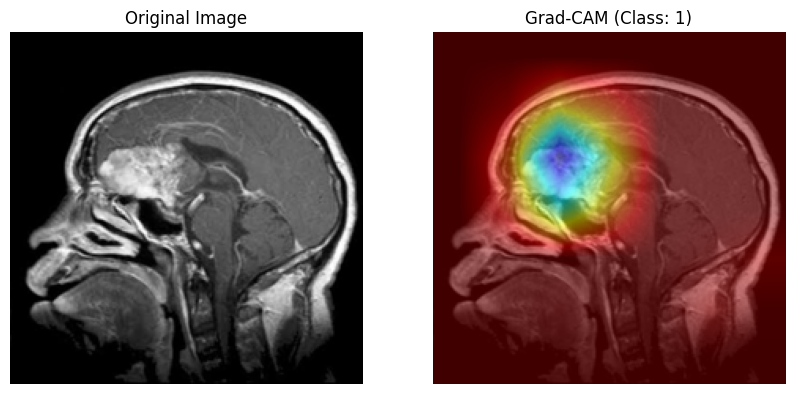

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], dtype=float32)

In [13]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2
from PIL import Image

# Parameters
MODEL_PATH = "/kaggle/working/RestNet101_Braintumor_class.h5"  # ResNet101 model path
TEST_IMAGE_PATH = "/kaggle/input/brain-tumor-classification-mri/Testing/glioma_tumor/image(10).jpg"
IMG_SIZE = (224, 224)

# Load the saved ResNet101 model
try:
    model = tf.keras.models.load_model(MODEL_PATH, compile=False)
    print("Model loaded successfully with compile=False")
except ValueError as e:
    print(f"Error loading model: {e}")
    # Fallback: Recreate ResNet101 and load weights
    from tensorflow.keras.applications import ResNet101
    base_model = ResNet101(weights=None, include_top=False, input_shape=(*IMG_SIZE, 3))
    x = base_model.output
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dropout(0.5)(x)
    x = tf.keras.layers.Dense(128, activation='relu')(x)
    x = tf.keras.layers.Dropout(0.3)(x)
    predictions = tf.keras.layers.Dense(4, activation='softmax')(x)  # Assuming 4 classes
    model = tf.keras.models.Model(inputs=base_model.input, outputs=predictions)
    model.load_weights(MODEL_PATH)
    print("Model recreated and weights loaded successfully")

# Image preprocessing function
def preprocess_image(image_path):
    img = Image.open(image_path).convert("RGB")
    img = img.resize(IMG_SIZE)
    img_array = np.array(img)
    img_array = tf.keras.applications.resnet.preprocess_input(img_array)  # ResNet preprocessing
    img_tensor = tf.expand_dims(img_array, axis=0)  # Add batch dimension
    return img_tensor, img

# Grad-CAM function
def generate_grad_cam(model, image_path, target_layer):
    # Load and preprocess image
    input_tensor, original_img = preprocess_image(image_path)

    # Get model predictions
    preds = model(input_tensor)
    pred_class = tf.argmax(preds[0]).numpy()

    # Define the gradient model
    grad_model = tf.keras.models.Model(
        [model.inputs], [model.get_layer(target_layer).output, model.output]
    )

    # Compute gradients
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(input_tensor)
        loss = predictions[:, pred_class]

    # Get gradients of the loss w.r.t. the convolutional outputs
    grads = tape.gradient(loss, conv_outputs)[0]

    # Global average pooling of gradients
    weights = tf.reduce_mean(grads, axis=(0, 1))  # Average over height and width
    conv_outputs = conv_outputs[0]  # Remove batch dimension

    # Compute the weighted sum (Grad-CAM heatmap)
    cam = tf.reduce_sum(tf.multiply(weights, conv_outputs), axis=-1)
    cam = tf.maximum(cam, 0)  # ReLU to keep positive values
    cam = cam.numpy()

    # Normalize and resize heatmap
    cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)  # Avoid division by zero
    cam = cv2.resize(cam, IMG_SIZE)

    # Overlay heatmap on original image
    heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
    img_cv = np.array(original_img)
    overlayed = cv2.addWeighted(img_cv, 0.5, heatmap, 0.5, 0)

    # Plot results
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(original_img)
    plt.title("Original Image")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(overlayed)
    plt.title(f"Grad-CAM (Class: {pred_class})")
    plt.axis('off')
    plt.show()

    return cam

# Select the last convolutional layer in ResNet101
target_layer = 'conv5_block3_out'  # Last conv layer in ResNet101 before pooling

# Run Grad-CAM
generate_grad_cam(model, TEST_IMAGE_PATH, target_layer)

Model loaded successfully with compile=False


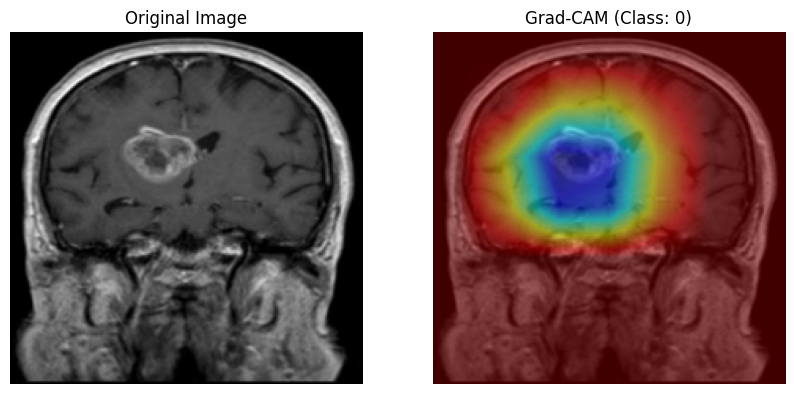

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], dtype=float32)

In [14]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2
from PIL import Image

# Parameters
MODEL_PATH = "/kaggle/working/RestNet101_Braintumor_class.h5"  # ResNet101 model path
TEST_IMAGE_PATH = "/kaggle/input/brain-tumor-classification-mri/Testing/glioma_tumor/image(12).jpg"
IMG_SIZE = (224, 224)

# Load the saved ResNet101 model
try:
    model = tf.keras.models.load_model(MODEL_PATH, compile=False)
    print("Model loaded successfully with compile=False")
except ValueError as e:
    print(f"Error loading model: {e}")
    # Fallback: Recreate ResNet101 and load weights
    from tensorflow.keras.applications import ResNet101
    base_model = ResNet101(weights=None, include_top=False, input_shape=(*IMG_SIZE, 3))
    x = base_model.output
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dropout(0.5)(x)
    x = tf.keras.layers.Dense(128, activation='relu')(x)
    x = tf.keras.layers.Dropout(0.3)(x)
    predictions = tf.keras.layers.Dense(4, activation='softmax')(x)  # Assuming 4 classes
    model = tf.keras.models.Model(inputs=base_model.input, outputs=predictions)
    model.load_weights(MODEL_PATH)
    print("Model recreated and weights loaded successfully")

# Image preprocessing function
def preprocess_image(image_path):
    img = Image.open(image_path).convert("RGB")
    img = img.resize(IMG_SIZE)
    img_array = np.array(img)
    img_array = tf.keras.applications.resnet.preprocess_input(img_array)  # ResNet preprocessing
    img_tensor = tf.expand_dims(img_array, axis=0)  # Add batch dimension
    return img_tensor, img

# Grad-CAM function
def generate_grad_cam(model, image_path, target_layer):
    # Load and preprocess image
    input_tensor, original_img = preprocess_image(image_path)

    # Get model predictions
    preds = model(input_tensor)
    pred_class = tf.argmax(preds[0]).numpy()

    # Define the gradient model
    grad_model = tf.keras.models.Model(
        [model.inputs], [model.get_layer(target_layer).output, model.output]
    )

    # Compute gradients
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(input_tensor)
        loss = predictions[:, pred_class]

    # Get gradients of the loss w.r.t. the convolutional outputs
    grads = tape.gradient(loss, conv_outputs)[0]

    # Global average pooling of gradients
    weights = tf.reduce_mean(grads, axis=(0, 1))  # Average over height and width
    conv_outputs = conv_outputs[0]  # Remove batch dimension

    # Compute the weighted sum (Grad-CAM heatmap)
    cam = tf.reduce_sum(tf.multiply(weights, conv_outputs), axis=-1)
    cam = tf.maximum(cam, 0)  # ReLU to keep positive values
    cam = cam.numpy()

    # Normalize and resize heatmap
    cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)  # Avoid division by zero
    cam = cv2.resize(cam, IMG_SIZE)

    # Overlay heatmap on original image
    heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
    img_cv = np.array(original_img)
    overlayed = cv2.addWeighted(img_cv, 0.5, heatmap, 0.5, 0)

    # Plot results
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(original_img)
    plt.title("Original Image")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(overlayed)
    plt.title(f"Grad-CAM (Class: {pred_class})")
    plt.axis('off')
    plt.show()

    return cam

# Select the last convolutional layer in ResNet101
target_layer = 'conv5_block3_out'  # Last conv layer in ResNet101 before pooling

# Run Grad-CAM
generate_grad_cam(model, TEST_IMAGE_PATH, target_layer)